# Figure 2: Phylogeography of H5N1 B3.13 cattle epidemic

Generates:
- **Fig 2** — 5-panel composite: MCC tree (A), epi curve (B), transitions by origin (C) / destination (D), first introduction timing (E)
- **S_TransitionPeak** — KDE peak timing of interstate transmissions
- **S_TransHeatmapByEraMedian** — Posterior median state-to-state transition matrices by era
- **S_AsymmetryCorrelateSet** — Transmission asymmetry index per state

All from correlateSet2enforced (time-inhomogeneous, 3 predictors, 3 eras, 3 rate scalars).

In [1]:
import re
import warnings
from collections import Counter, defaultdict
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.transforms as mtransforms
from matplotlib import gridspec
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch, Patch
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

warnings.filterwarnings("ignore", category=FutureWarning)

# -- Paths ------------------------------------------------------------------
PROJ_ROOT = Path("../..").resolve()
FINAL_DIR = PROJ_ROOT / "paper" / "final"
DATA_DIR = FINAL_DIR / "data"
BEAST_DIR = FINAL_DIR / "analysis/beast"
FIG_DIR = FINAL_DIR / "figures"
TABLE_DIR = FINAL_DIR / "tables"
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

_CORR2E_DIR = BEAST_DIR / "phylogeography/correlateSet2e"
_PREFIX = "timeinhomogeneous_correlateSet2enforced_weeklyEpochs_3era_3rateScalar"

EPI_CSV = DATA_DIR / "epi/USDA_h5n1_cattle_poultry_outbreaks_2024-01-01_to_2025-12-21.noD11noPoultry.csv"
WAHIS_CSV = DATA_DIR / "epi/WAHIS_USDA_bovine_outbreaks.csv"
WAHIS_CSV = DATA_DIR / "epi/WAHIS_USDA_bovine_outbreaks_correct_v2.csv"
GLM_3ERA_LOG = _CORR2E_DIR / f"{_PREFIX}.log"
JUMP_HISTORY_LOG = _CORR2E_DIR / f"{_PREFIX}.jumpHistory.log"
HIPSTR_TREE = _CORR2E_DIR / f"{_PREFIX}.burninRemovedResampled.hipstr.tree"

# -- Key dates --------------------------------------------------------------
TMRCA_DATE = datetime(2023, 12, 16)
TX_DETECT = datetime(2024, 3, 25)
FED_ORDER = datetime(2024, 4, 29)
MRTP = 2025.8219

# -- Epoch colours -----------------------------------------------------------
COL_CRYPTIC   = "#D55E00"
COL_EXPANSION = "#E69F00"
COL_POST      = "#0072B2"
EPOCH_COLS = [COL_CRYPTIC, COL_EXPANSION, COL_POST]
EPOCH_LABELS = ["Pre-detection", "Pre-response", "Post-response"]

# -- State colours (2-letter for tree) --------------------------------------
TREE_STATE_COLORS = {
    "CA": "#ff7f00", "TX": "#e41a1c", "ID": "#7b3294", "CO": "#2166ac",
    "IA": "#1b9e77", "MN": "#00838f", "MI": "#8c6d31", "OH": "#c51b7d",
    "NM": "#b2abd2", "WY": "#a6d854", "SD": "#fc8d62", "KS": "#ffd92f",
    "UT": "#e5c494", "NE": "#b3b3b3", "OK": "#d9d9d9", "NC": "#66c2a5",
    "NV": "#999999",
}

# -- State full names -------------------------------------------------------
STATE_FULL_NAMES = {
    "CA": "California", "TX": "Texas", "ID": "Idaho", "CO": "Colorado",
    "IA": "Iowa", "MN": "Minnesota", "MI": "Michigan", "OH": "Ohio",
    "NM": "New Mexico", "WY": "Wyoming", "SD": "South Dakota", "KS": "Kansas",
    "UT": "Utah", "NE": "Nebraska", "OK": "Oklahoma", "NC": "North Carolina",
    "NV": "Nevada",
}

# -- State colours (full name for epi curve) --------------------------------
STATE_COLORS = {
    "Texas": "#e41a1c", "California": "#ff7f00", "Idaho": "#7b3294",
    "Colorado": "#2166ac", "Iowa": "#1b9e77", "Minnesota": "#00838f",
    "Michigan": "#8c6d31", "Ohio": "#c51b7d", "New Mexico": "#b2abd2",
    "Wyoming": "#a6d854", "South Dakota": "#fc8d62", "Kansas": "#ffd92f",
    "Utah": "#e5c494", "Nebraska": "#b3b3b3", "Oklahoma": "#d9d9d9",
    "North Carolina": "#66c2a5", "Nevada": "#888888",
}

STATE_ABBREV = {
    "Texas": "TX", "California": "CA", "Idaho": "ID", "Colorado": "CO",
    "Iowa": "IA", "Minnesota": "MN", "Michigan": "MI", "Ohio": "OH",
    "New Mexico": "NM", "Wyoming": "WY", "South Dakota": "SD",
    "Kansas": "KS", "Utah": "UT", "Nebraska": "NE", "Oklahoma": "OK",
    "North Carolina": "NC",
}

STATE_ORDER = sorted(TREE_STATE_COLORS.keys())

# -- Font setup -------------------------------------------------------------
for font in ["Arial", "Helvetica", "DejaVu Sans"]:
    try:
        matplotlib.font_manager.findfont(font, fallback_to_default=False)
        plt.rcParams["font.family"] = "sans-serif"
        plt.rcParams["font.sans-serif"] = [font]
        break
    except ValueError:
        continue

plt.rcParams.update({
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -- Shared x-axis limits ---------------------------------------------------
XLIM = (datetime(2023, 10, 1), datetime(2025, 12, 1))

In [2]:
def decimal_to_date(dec_year):
    year = int(dec_year)
    remainder = dec_year - year
    return datetime(year, 1, 1) + timedelta(days=remainder * 365.25)


def hpd(samples, credible_mass=0.95):
    sorted_samples = np.sort(samples)
    n = len(sorted_samples)
    interval_size = int(np.ceil(credible_mass * n))
    widths = sorted_samples[interval_size:] - sorted_samples[:n - interval_size]
    best = int(np.argmin(widths))
    return sorted_samples[best], sorted_samples[best + interval_size - 1]


def hpd_dates(dates, credible_mass=0.95):
    sorted_dates = sorted(dates)
    n = len(sorted_dates)
    interval_size = int(np.ceil(credible_mass * n))
    best_width = None
    best_idx = 0
    for i in range(n - interval_size + 1):
        width = (sorted_dates[i + interval_size - 1] - sorted_dates[i]).total_seconds()
        if best_width is None or width < best_width:
            best_width = width
            best_idx = i
    return sorted_dates[best_idx], sorted_dates[best_idx + interval_size - 1]


def assign_era(dt):
    if dt < TX_DETECT:
        return "Pre-detection"
    elif dt < FED_ORDER:
        return "Pre-response"
    else:
        return "Post-response"


def _add_vlines(ax):
    kw = dict(linestyle="--", linewidth=0.8, zorder=5)
    ax.axvline(TX_DETECT, color=COL_CRYPTIC, alpha=0.7, **kw)
    ax.axvline(FED_ORDER, color=COL_POST, alpha=0.7, **kw)


def _add_era_shading(ax):
    ax.axvspan(XLIM[0], TX_DETECT, color=COL_CRYPTIC, alpha=0.04, zorder=0)
    ax.axvspan(TX_DETECT, FED_ORDER, color=COL_EXPANSION, alpha=0.04, zorder=0)
    ax.axvspan(FED_ORDER, XLIM[1], color=COL_POST, alpha=0.04, zorder=0)


def _format_time_axis(ax, show_labels=True):
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax.set_xlim(*XLIM)
    if show_labels:
        # ax.set_xlabel("Date")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n'%y"))
        plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    else:
        ax.tick_params(labelbottom=False)


def _panel_label(ax, label, x=-0.04, y=1.05):
    ax.text(x, y, label, transform=ax.transAxes, fontsize=12,
            fontweight="bold", va="top", ha="right")

## Data loading

Shared across all figures: Baltic tree, epi data, jump history, posterior transitions, intro timing.

In [3]:
_TREE_CACHE = {}


def load_baltic_tree():
    if "data" in _TREE_CACHE:
        return _TREE_CACHE["data"]

    import baltic as bt

    print("  Loading hipstr tree with baltic...")
    tree = bt.loadNexus(str(HIPSTR_TREE),
                        tip_regex=r'\|([0-9]{4}-[0-9]{2}-[0-9]{2})\|',
                        verbose=False)
    tree.sortBranches()
    tree.drawTree()

    all_y = [n.y for n in tree.Objects]
    max_y = max(all_y)

    for node in tree.Objects:
        node.y = max_y - node.y

    obj_set = set(id(n) for n in tree.Objects)

    children_map = {}
    for node in tree.Objects:
        if node.parent and id(node.parent) in obj_set:
            pid = id(node.parent)
            children_map.setdefault(pid, []).append(node)

    h_lines = []
    h_colors = []
    v_lines = []
    v_colors = []

    for node in tree.Objects:
        nid = id(node)
        state = node.traits.get('loc.states', '??')
        color = TREE_STATE_COLORS.get(state, '#aaaaaa')

        if node.parent and id(node.parent) in obj_set:
            x0 = decimal_to_date(node.parent.absoluteTime)
            x1 = decimal_to_date(node.absoluteTime)
            h_lines.append([(mdates.date2num(x0), node.y),
                            (mdates.date2num(x1), node.y)])
            h_colors.append(color)

        kids = children_map.get(nid, [])
        if kids:
            ys = [c.y for c in kids]
            xn = mdates.date2num(decimal_to_date(node.absoluteTime))
            v_lines.append([(xn, min(ys)), (xn, max(ys))])
            v_colors.append(color)

    transitions = []
    for node in tree.Objects:
        if node.parent and id(node.parent) in obj_set:
            p_state = node.parent.traits.get('loc.states', '??')
            c_state = node.traits.get('loc.states', '??')
            p_prob = node.parent.traits.get('loc.states.prob', 0)
            c_prob = node.traits.get('loc.states.prob', 0)
            try:
                p_prob = float(p_prob)
            except (TypeError, ValueError):
                p_prob = 0
            try:
                c_prob = float(c_prob)
            except (TypeError, ValueError):
                c_prob = 0
            if p_state != c_state and p_prob >= 0.5 and c_prob >= 0.5:
                transitions.append({
                    'date': decimal_to_date(node.absoluteTime),
                    'y': node.y,
                    'origin': p_state,
                    'destination': c_state,
                })

    n_tips = len(tree.getExternal())
    result = {
        "h_lines": h_lines, "h_colors": h_colors,
        "v_lines": v_lines, "v_colors": v_colors,
        "transitions": transitions,
        "n_tips": n_tips,
        "max_y": max_y,
    }
    _TREE_CACHE["data"] = result
    print(f"  Tree loaded: {n_tips} tips, {len(transitions)} transitions")
    return result


def load_epi_data():
    df = pd.read_csv(EPI_CSV)
    df["date"] = pd.to_datetime(df["Confirmation Date"], format="%d-%b-%y")
    return df


_JUMP_CACHE = {}
_JUMP_PATTERN = re.compile(r'\{1,([\d.]+),(\w+),(\w+)\}')


def load_jump_history():
    if "data" in _JUMP_CACHE:
        return _JUMP_CACHE["data"]

    print("  Loading jump history...")
    histories = []
    with open(JUMP_HISTORY_LOG) as f:
        for line in f:
            if line.startswith('#') or line.startswith('state'):
                continue
            parts = line.strip().split('\t')
            if len(parts) < 3:
                continue
            histories.append(parts[2])

    n_burnin = len(histories) // 10
    histories = histories[n_burnin:]
    print(f"  {len(histories)} post-burnin samples")

    samples = []
    for hist_str in histories:
        matches = _JUMP_PATTERN.findall(hist_str)
        jumps = []
        for h_str, src, dest in matches:
            h = float(h_str)
            cal_date = decimal_to_date(MRTP - h)
            jumps.append((cal_date, src, dest))
        samples.append(jumps)

    _JUMP_CACHE["data"] = samples
    return samples


def _parse_earliest_genomes_from_tree():
    taxon_re = re.compile(r"USA-([A-Z]{2})\|(\d{4}-\d{2}-\d{2})")
    earliest = {}
    with open(HIPSTR_TREE) as f:
        for line in f:
            if "Translate" in line or line.strip().startswith("tree "):
                break
            for m in taxon_re.finditer(line):
                state, date_str = m.group(1), m.group(2)
                dt = pd.Timestamp(date_str)
                if state not in earliest or dt < earliest[state]:
                    earliest[state] = dt
        for line in f:
            if line.strip().startswith(";"):
                break
            for m in taxon_re.finditer(line):
                state, date_str = m.group(1), m.group(2)
                dt = pd.Timestamp(date_str)
                if state not in earliest or dt < earliest[state]:
                    earliest[state] = dt
    return earliest


_DATE_COLS = ["Median intro (date)", "95% HPD lower", "95% HPD upper",
              "Earliest genome", "Earliest outbreak"]


def compute_intro_timing():
    samples = load_jump_history()

    epi = pd.read_csv(EPI_CSV)
    epi["date"] = pd.to_datetime(epi["Confirmation Date"], format="%d-%b-%y")

    earliest_outbreak = {}
    for _, row in epi.iterrows():
        abbr = STATE_ABBREV.get(row["State"])
        if abbr and (abbr not in earliest_outbreak or row["date"] < earliest_outbreak[abbr]):
            earliest_outbreak[abbr] = row["date"]

    earliest_genome = _parse_earliest_genomes_from_tree()

    first_intro_dates = defaultdict(list)
    for sample_jumps in samples:
        state_first = {}
        for cal_date, src, dest in sample_jumps:
            if dest not in state_first or cal_date < state_first[dest]:
                state_first[dest] = cal_date
        for state, dt in state_first.items():
            first_intro_dates[state].append(dt)

    rows = []
    root_heights = []
    with open(GLM_3ERA_LOG) as f:
        header_idx = None
        for line in f:
            if line.startswith("#"):
                continue
            cols = line.strip().split("\t")
            if header_idx is None:
                header_idx = cols.index("treeModel.rootHeight")
                continue
            root_heights.append(float(cols[header_idx]))
    n_burnin_log = len(root_heights) // 10
    root_heights = root_heights[n_burnin_log:]
    tx_dates = [decimal_to_date(MRTP - h) for h in root_heights]
    if tx_dates:
        med = sorted(tx_dates)[len(tx_dates) // 2]
        lo, hi = hpd_dates(tx_dates)
        ob = earliest_outbreak.get("TX", pd.NaT)
        lag = (ob - med).days if pd.notna(ob) and med else ""
        gen = earliest_genome.get("TX", "")
        gen_str = gen.strftime("%Y-%m-%d") if isinstance(gen, pd.Timestamp) else ""
        gen_lag = ""
        if gen_str and med:
            gen_lag = (pd.Timestamp(gen_str) - med).days
        rows.append({
            "State": "TX", "Type": "tMRCA",
            "Median intro (date)": med.strftime("%Y-%m-%d"),
            "95% HPD lower": lo.strftime("%Y-%m-%d"),
            "95% HPD upper": hi.strftime("%Y-%m-%d"),
            "N posterior samples": len(tx_dates),
            "Earliest genome": gen_str,
            "Earliest outbreak": ob.strftime("%Y-%m-%d") if pd.notna(ob) else "",
            "Lag intro→genome (days)": gen_lag,
            "Lag intro→outbreak (days)": lag,
        })

    for state in sorted(first_intro_dates.keys()):
        if state == "TX":
            continue
        dates = first_intro_dates[state]
        if not dates:
            continue
        med = sorted(dates)[len(dates) // 2]
        lo, hi = hpd_dates(dates)
        ob = earliest_outbreak.get(state, pd.NaT)
        lag = (ob - med).days if pd.notna(ob) and med else ""
        gen = earliest_genome.get(state, "")
        gen_str = gen.strftime("%Y-%m-%d") if isinstance(gen, pd.Timestamp) else ""
        gen_lag = ""
        if gen_str and med:
            gen_lag = (pd.Timestamp(gen_str) - med).days
        rows.append({
            "State": state, "Type": "1st intro",
            "Median intro (date)": med.strftime("%Y-%m-%d"),
            "95% HPD lower": lo.strftime("%Y-%m-%d"),
            "95% HPD upper": hi.strftime("%Y-%m-%d"),
            "N posterior samples": len(dates),
            "Earliest genome": gen_str,
            "Earliest outbreak": ob.strftime("%Y-%m-%d") if pd.notna(ob) else "",
            "Lag intro→genome (days)": gen_lag,
            "Lag intro→outbreak (days)": lag,
        })

    df = pd.DataFrame(rows)
    intro_csv = TABLE_DIR / "intro_timing_table.csv"
    df.to_csv(intro_csv, index=False)
    print(f"  Saved intro timing to {intro_csv}")
    for col in _DATE_COLS:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def load_intro_timing():
    intro_csv = TABLE_DIR / "intro_timing_table.csv"
    if not intro_csv.exists():
        print("  Intro CSV not found, regenerating from jump history...")
        return compute_intro_timing()
    return pd.read_csv(intro_csv, parse_dates=_DATE_COLS)


# -- Epoch transition times and bin helpers ----------------------------------

_EPOCH_TRANSITION_TIMES = [
    0.0164383562, 0.0356164384, 0.0547945205, 0.0739726027, 0.0931506849,
    0.1123287671, 0.1315068493, 0.1506849315, 0.1698630137, 0.1890410959,
    0.2082191781, 0.2273972603, 0.2465753425, 0.2657534247, 0.2849315068,
    0.3041095890, 0.3232876712, 0.3424657534, 0.3616438356, 0.3808219178,
    0.4000000000, 0.4191780822, 0.4383561644, 0.4575342466, 0.4767123288,
    0.4958904110, 0.5150684932, 0.5342465753, 0.5534246575, 0.5726027397,
    0.5917808219, 0.6109589041, 0.6301369863, 0.6493150685, 0.6657534247,
    0.6849315068, 0.7041095890, 0.7232876712, 0.7424657534, 0.7616438356,
    0.7808219178, 0.8000000000, 0.8191780822, 0.8383112508, 0.8574369339,
    0.8765626170, 0.8956883000, 0.9148139831, 0.9339396661, 0.9530653492,
    0.9721910323, 0.9967811962, 1.0159068793, 1.0350325623, 1.0541582454,
    1.0732839284, 1.0924096115, 1.1115352946, 1.1306609776, 1.1497866607,
    1.1689123437, 1.1880380268, 1.2071637099, 1.2262893929, 1.2454150760,
    1.2645407590, 1.2836664421, 1.3027921252, 1.3219178082, 1.3410434913,
    1.3601691743, 1.3792948574, 1.3984205405, 1.4175462235, 1.4366719066,
    1.4557975896, 1.4749232727, 1.4940489558, 1.5131746388, 1.5323003219,
    1.5514260049, 1.5705516880, 1.5896773711, 1.6088030541, 1.6279287372,
    1.6470544202, 1.6661801033, 1.6853057864, 1.7044314694, 1.7235571525,
    1.7426828355, 1.7618085186, 1.7809342017, 1.8000598847, 1.8191855678,
    1.8383561644, 1.8575342466, 1.8767123288, 1.8958904110, 1.9150684932,
    1.9342465753, 1.9534246575, 1.9726027397,
]


def _make_weekly_bins():
    boundaries = sorted(
        [datetime.combine(decimal_to_date(MRTP - t).date(), datetime.min.time())
         for t in _EPOCH_TRANSITION_TIMES]
    )
    oldest = boundaries[0]
    start_edge = oldest - timedelta(days=7)
    end_edge = decimal_to_date(MRTP) + timedelta(days=1)
    return [start_edge] + boundaries + [end_edge]


def _epoch_bin_starts_and_widths():
    bins = _make_weekly_bins()
    left_edges = []
    widths = []
    for i in range(len(bins) - 1):
        left_edges.append(bins[i])
        w = (bins[i + 1] - bins[i]).days
        widths.append(w)
    return left_edges, widths


def load_posterior_transitions():
    if "posterior_trans" in _JUMP_CACHE:
        return _JUMP_CACHE["posterior_trans"]

    samples = load_jump_history()
    week_bins = _make_weekly_bins()
    n_bins = len(week_bins) - 1
    left_edges, widths = _epoch_bin_starts_and_widths()

    all_states = set()
    for sample_jumps in samples:
        for _, src, dest in sample_jumps:
            all_states.add(src)
            all_states.add(dest)

    n_samples = len(samples)
    origin_samples = {s: np.zeros((n_samples, n_bins)) for s in all_states}
    dest_samples = {s: np.zeros((n_samples, n_bins)) for s in all_states}

    for si, sample_jumps in enumerate(samples):
        for cal_date, src, dest in sample_jumps:
            for bi in range(n_bins):
                if week_bins[bi] <= cal_date < week_bins[bi + 1]:
                    origin_samples[src][si, bi] += 1
                    dest_samples[dest][si, bi] += 1
                    break

    first_seen = {}
    for sample_jumps in samples:
        for cal_date, src, dest in sample_jumps:
            for s in [src, dest]:
                if s not in first_seen or cal_date < first_seen[s]:
                    first_seen[s] = cal_date
    states_ordered = sorted(all_states, key=lambda s: first_seen.get(s, datetime.max))

    origin_counts = {}
    dest_counts = {}
    for s in states_ordered:
        origin_counts[s] = np.mean(origin_samples[s], axis=0)
        dest_counts[s] = np.mean(dest_samples[s], axis=0)

    result = (left_edges, widths, origin_counts, dest_counts, states_ordered)
    _JUMP_CACHE["posterior_trans"] = result
    return result


print("Loading data...")
_ = load_baltic_tree()
_ = load_jump_history()
_ = load_posterior_transitions()
print("All data loaded.")

Loading data...
  Loading hipstr tree with baltic...
  Tree loaded: 3950 tips, 58 transitions
  Loading jump history...
  90001 post-burnin samples
All data loaded.


---
## Figure 2 — Panel drawing functions

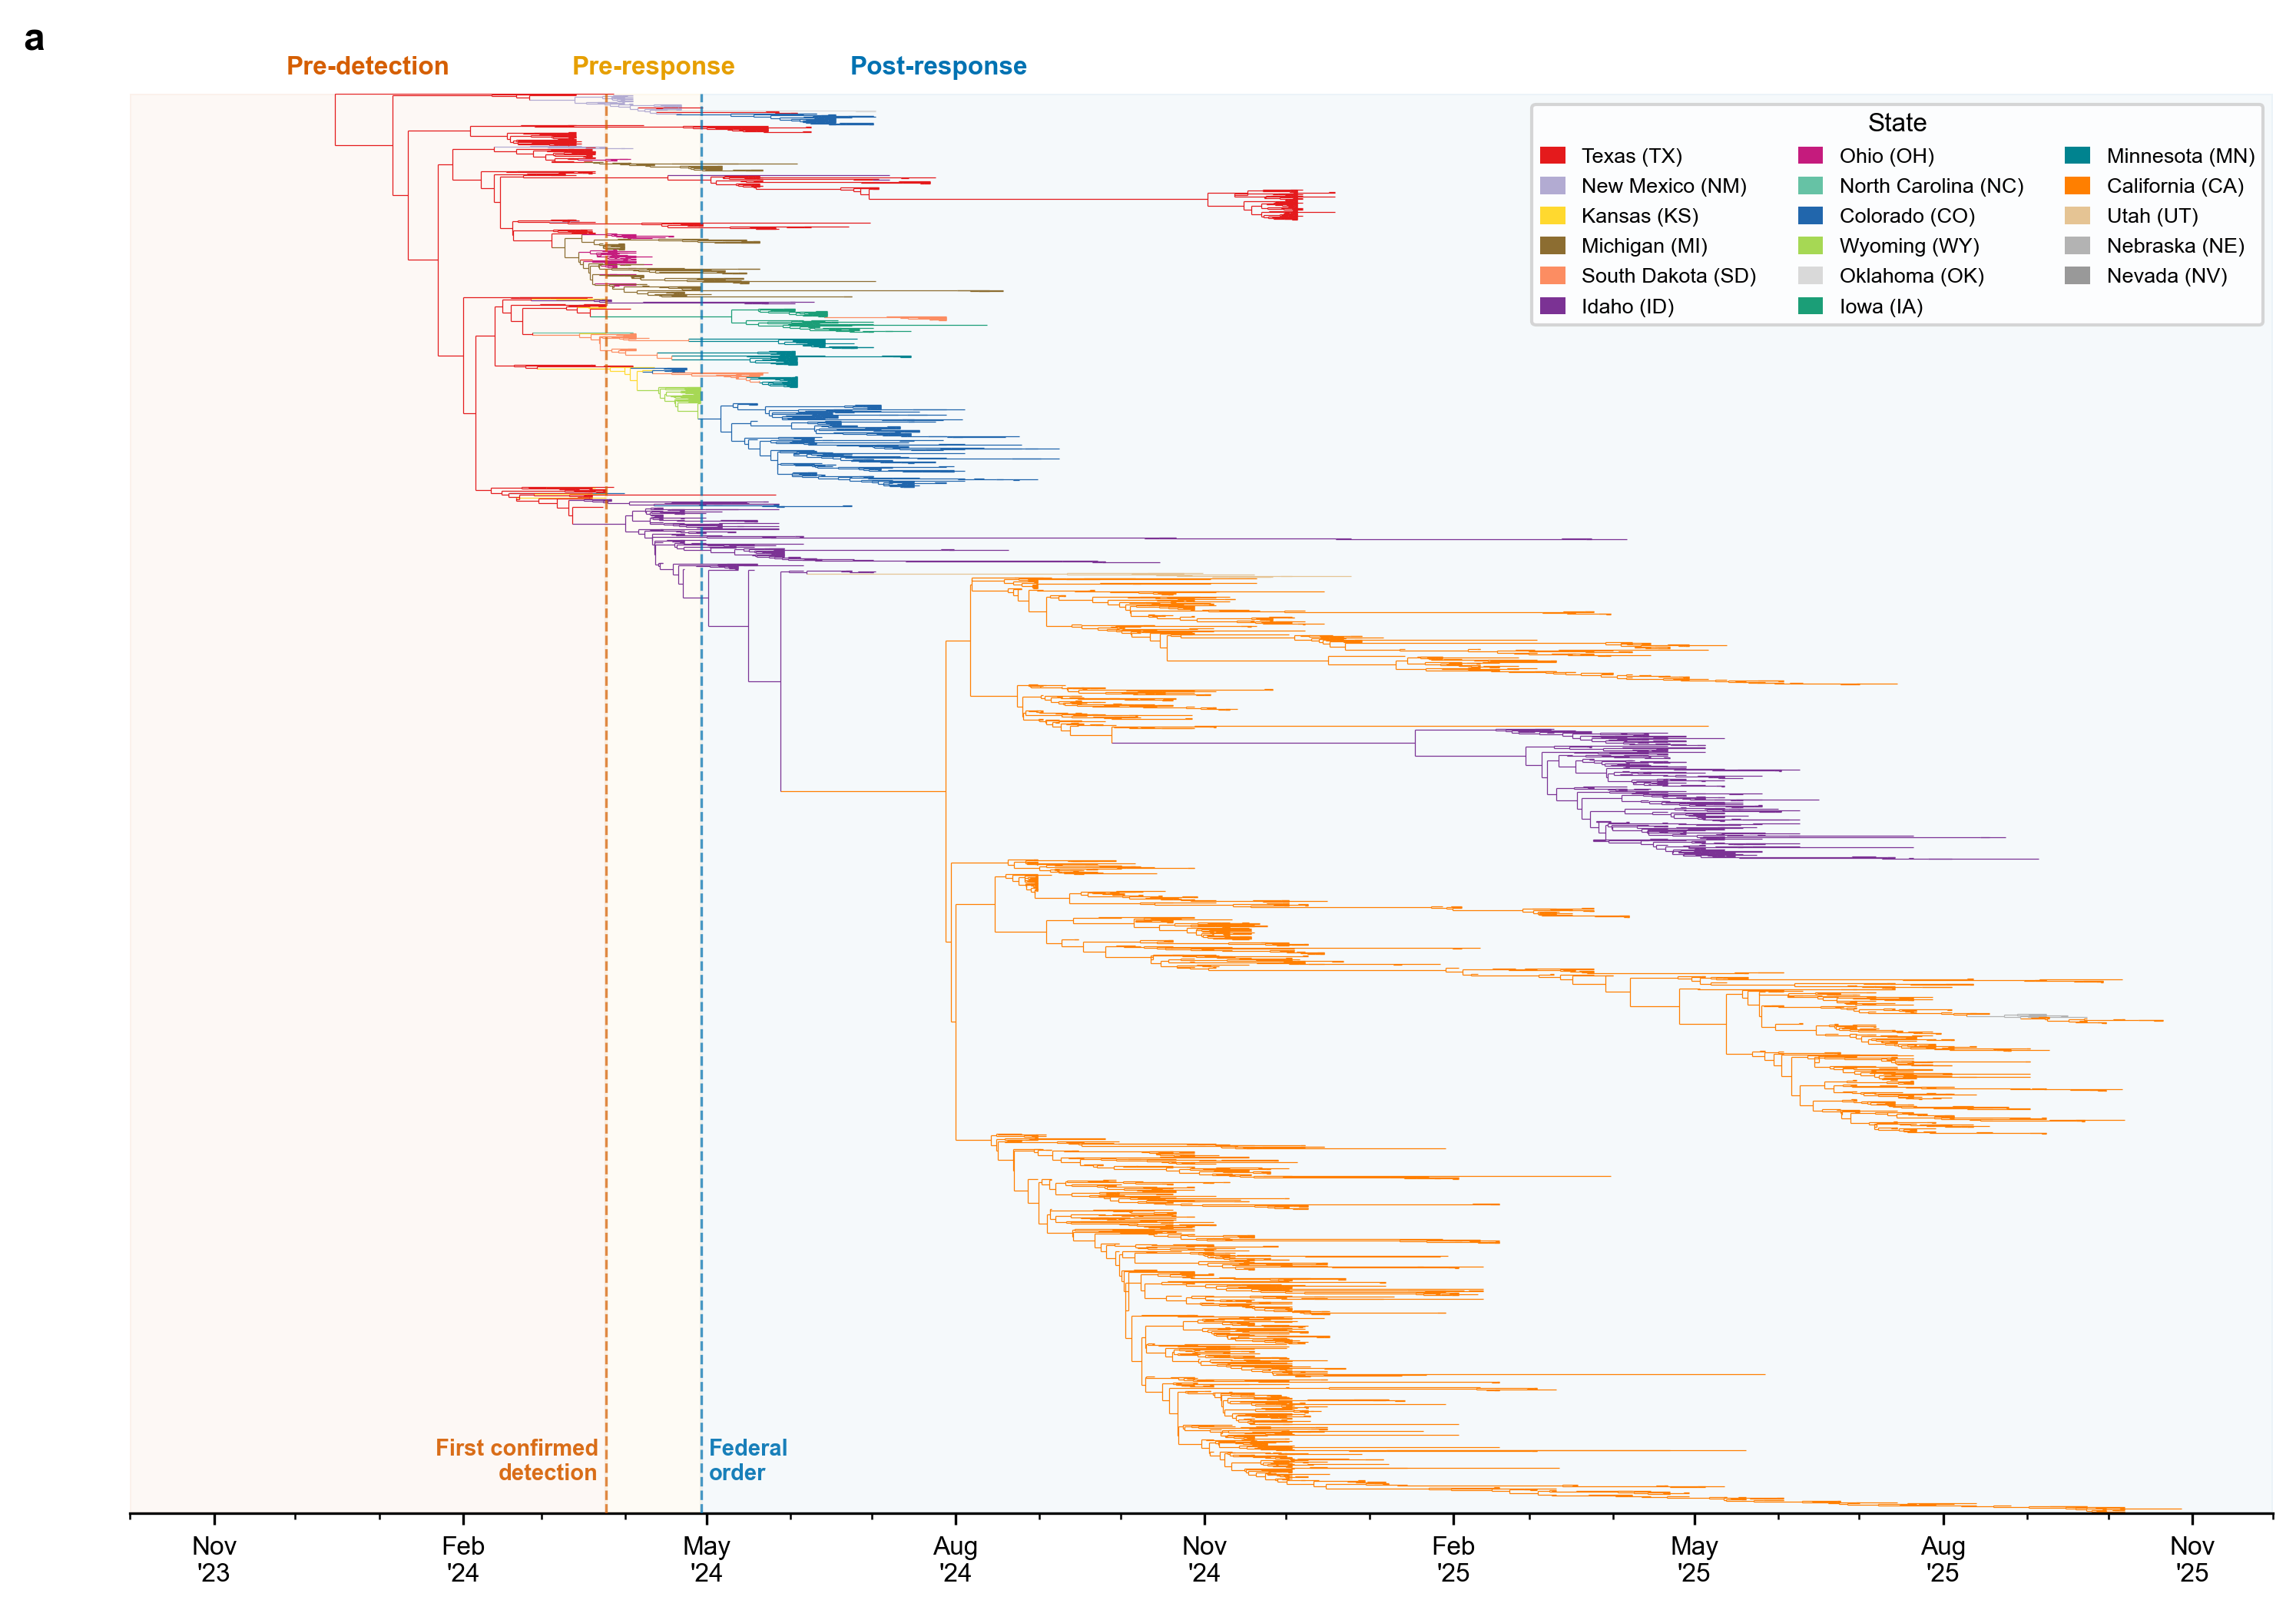

In [4]:
def draw_panel_A(ax, show_labels=False, label="a"):
    _panel_label(ax, label)
    tree_data = load_baltic_tree()

    lc_h = LineCollection(tree_data["h_lines"], colors=tree_data["h_colors"],
                          linewidths=0.3, zorder=2)
    lc_v = LineCollection(tree_data["v_lines"], colors=tree_data["v_colors"],
                          linewidths=0.3, zorder=2)
    ax.add_collection(lc_h)
    ax.add_collection(lc_v)

    ax.set_xlim(mdates.date2num(XLIM[0]), mdates.date2num(XLIM[1]))
    ax.set_ylim(-0.5, tree_data["max_y"] + 0.5)
    ax.invert_yaxis()

    ax.set_yticks([])
    ax.xaxis_date()
    _format_time_axis(ax, show_labels=show_labels)
    _add_era_shading(ax)
    _add_vlines(ax)

    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

    ax.text(mdates.date2num(TX_DETECT) - 3, 0.02, "First confirmed\ndetection",
            transform=trans, fontsize=7, color=COL_CRYPTIC, alpha=0.9,
            ha="right", va="bottom", fontweight="bold")
    ax.text(mdates.date2num(FED_ORDER) + 3, 0.02, "Federal\norder",
            transform=trans, fontsize=7, color=COL_POST, alpha=0.9,
            ha="left", va="bottom", fontweight="bold")

    cryptic_center = mdates.date2num(XLIM[0] + (TX_DETECT - XLIM[0]) / 2)
    expansion_center = mdates.date2num(TX_DETECT + (FED_ORDER - TX_DETECT) / 2)
    post_policy_x = expansion_center + (expansion_center - cryptic_center)

    ax.text(cryptic_center, 1.01, "Pre-detection", transform=trans,
            fontsize=8, color=COL_CRYPTIC, ha="center", va="bottom",
            fontweight="bold", clip_on=False)
    ax.text(expansion_center, 1.01, "Pre-response", transform=trans,
            fontsize=8, color=COL_EXPANSION, ha="center", va="bottom",
            fontweight="bold", clip_on=False)
    ax.text(post_policy_x, 1.01, "Post-response", transform=trans,
            fontsize=8, color=COL_POST, ha="center", va="bottom",
            fontweight="bold", clip_on=False)

    for spine in ["left", "top", "right"]:
        ax.spines[spine].set_visible(False)

    first_appear = {}
    for t in tree_data["transitions"]:
        for s in [t["origin"], t["destination"]]:
            if s not in first_appear or t["date"] < first_appear[s]:
                first_appear[s] = t["date"]
    for s in TREE_STATE_COLORS:
        if s not in first_appear:
            first_appear[s] = datetime.max
    state_order = sorted(TREE_STATE_COLORS.keys(), key=lambda s: first_appear[s])
    legend_handles = [
        Patch(facecolor=TREE_STATE_COLORS[s], edgecolor="none",
              label=f"{STATE_FULL_NAMES[s]} ({s})")
        for s in state_order
    ]
    ax.legend(handles=legend_handles, loc="upper right", ncol=3, fontsize=6.5,
              framealpha=0.8, handlelength=1.2, handleheight=0.9,
              title="State", title_fontsize=8)
    
    # add xticklabels
    


fig_a, ax_a = plt.subplots(figsize=(12, 8))
draw_panel_A(ax_a, show_labels=True)
_format_time_axis(ax_a, show_labels=True)
# plt.savefig('../figures/fig2.panelA.png')
plt.show()

/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_91587/1865403043.py:61: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect, connectors = ax.indicate_inset_zoom(inset, edgecolor="grey", alpha=0.6,


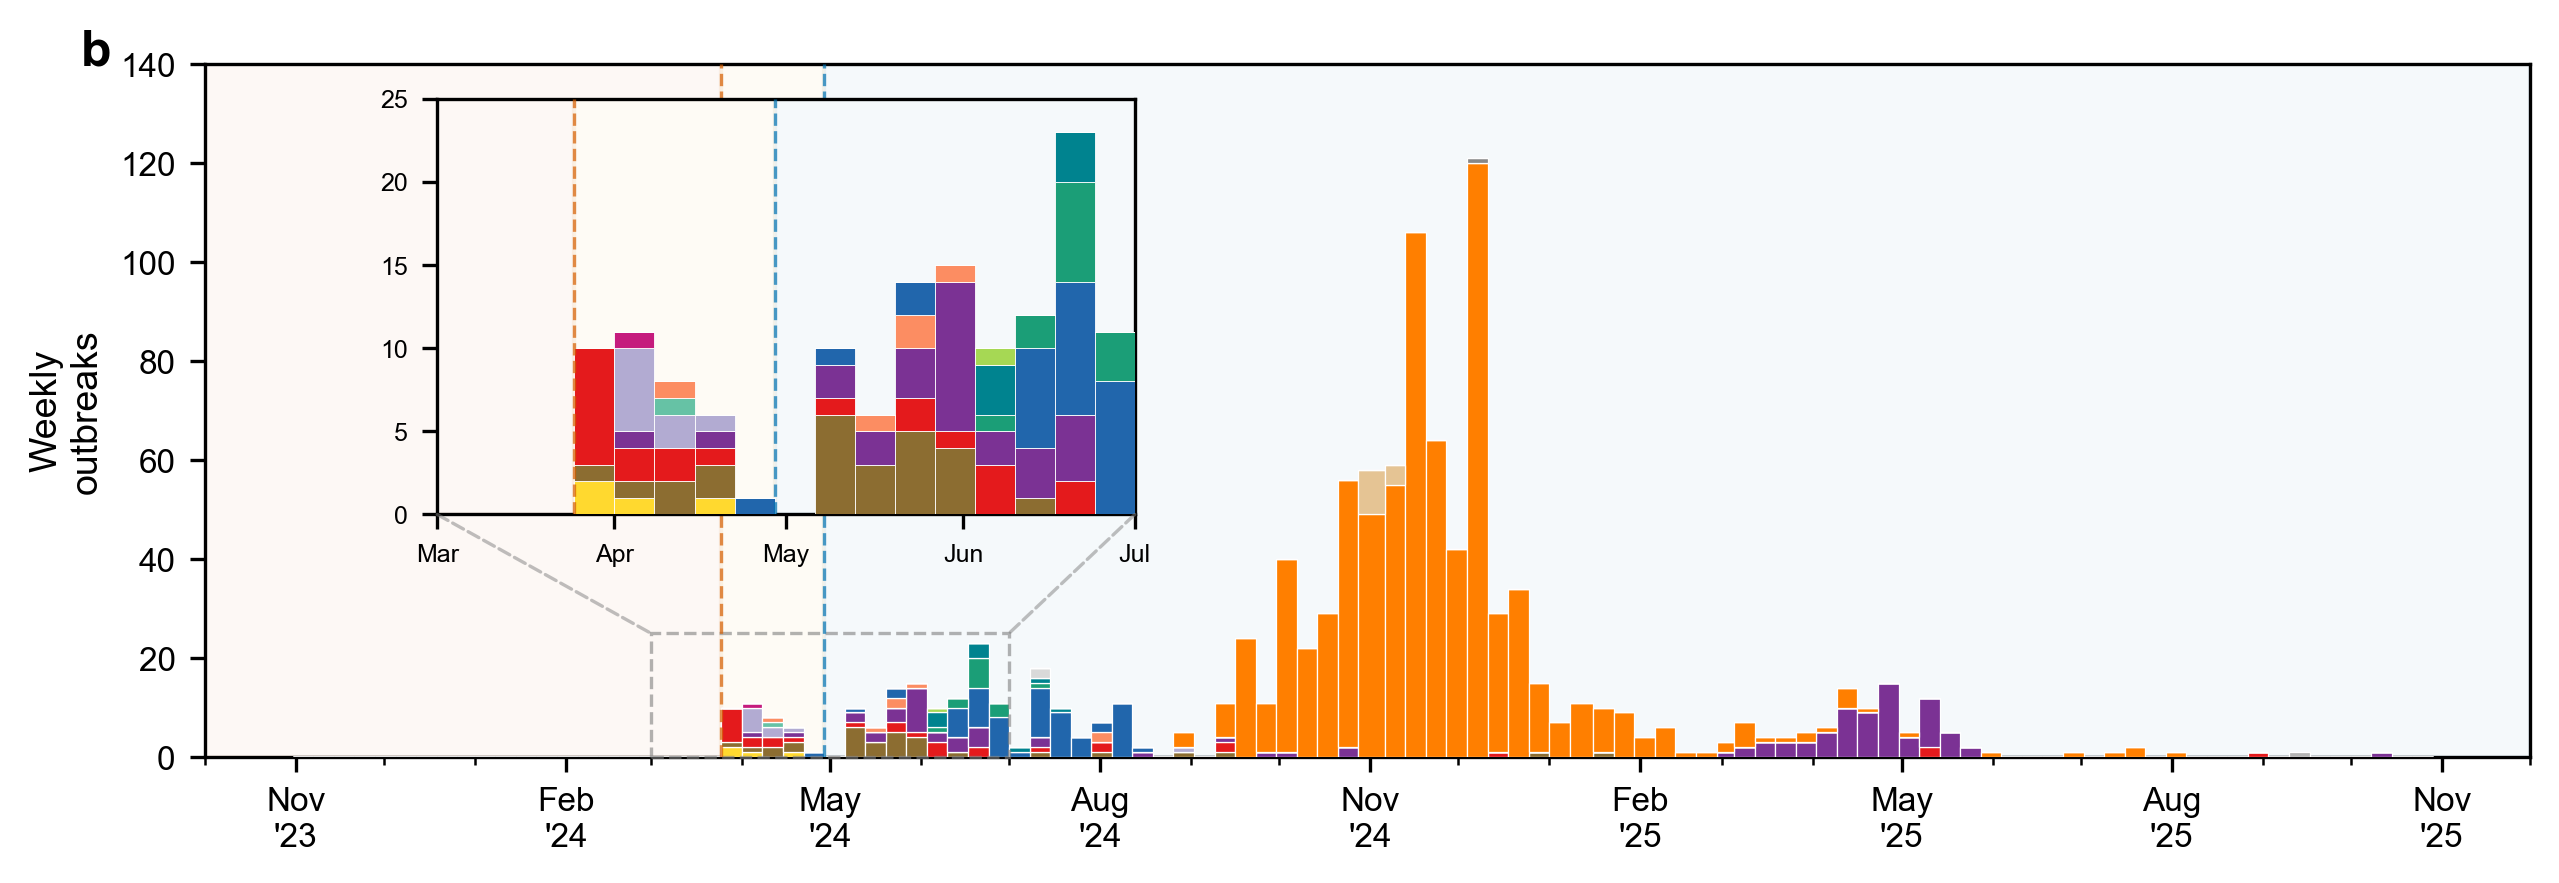

In [5]:
def draw_panel_B(ax, show_labels=False, label="b"):
    _panel_label(ax, label)
    df = load_epi_data()
    df = df.dropna(subset=["date"]).copy()

    week_bins = _make_weekly_bins()
    bin_starts = week_bins[:-1]
    left_edges, widths = _epoch_bin_starts_and_widths()

    df["bin_idx"] = pd.cut(df["date"], bins=week_bins, labels=range(len(bin_starts)),
                           right=False)
    df = df.dropna(subset=["bin_idx"])
    df["bin_idx"] = df["bin_idx"].astype(int)

    pivot = df.groupby(["bin_idx", "State"]).size().unstack(fill_value=0)
    pivot = pivot.reindex(range(len(bin_starts)), fill_value=0)

    first_appearance = {}
    for state in pivot.columns:
        nonzero = pivot[state][pivot[state] > 0]
        if len(nonzero) > 0:
            first_appearance[state] = nonzero.index[0]
        else:
            first_appearance[state] = len(bin_starts)
    chrono_order = sorted(pivot.columns, key=lambda s: first_appearance[s])
    pivot = pivot[chrono_order]

    bottom = np.zeros(len(left_edges))

    for state in pivot.columns:
        vals = pivot[state].values.astype(float)
        color = STATE_COLORS.get(state, "#cccccc")
        ax.bar(left_edges, vals, width=[timedelta(days=w) for w in widths],
               bottom=bottom, color=color, edgecolor="white", linewidth=0.3, label=state,
               align="edge", zorder=3)
        bottom += vals

    ax.set_ylabel("Weekly\noutbreaks")
    ax.set_ylim(0, 140)
    _add_era_shading(ax)
    _add_vlines(ax)
    _format_time_axis(ax, show_labels=show_labels)

    inset = ax.inset_axes([0.10, 0.35, 0.30, 0.60])
    bottom_in = np.zeros(len(left_edges))
    for state in pivot.columns:
        vals = pivot[state].values.astype(float)
        color = STATE_COLORS.get(state, "#cccccc")
        inset.bar(left_edges, vals, width=[timedelta(days=w) for w in widths],
                  bottom=bottom_in, color=color, edgecolor="white", linewidth=0.2,
                  align="edge", zorder=3)
        bottom_in += vals
    inset.set_xlim(datetime(2024, 3, 1), datetime(2024, 7, 1))
    inset.set_ylim(0, 25)
    inset.xaxis.set_major_locator(mdates.MonthLocator())
    inset.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    inset.tick_params(labelsize=6)
    inset.set_ylabel("", fontsize=6)
    _add_era_shading(inset)
    _add_vlines(inset)
    rect, connectors = ax.indicate_inset_zoom(inset, edgecolor="grey", alpha=0.6,
                                                linestyle="--", linewidth=0.8)
    for c in connectors:
        if c is not None:
            c.set_visible(False)
    rect_bbox = rect.get_bbox()
    for x_frac, x_rect in [(0.0, rect_bbox.x0), (1.0, rect_bbox.x1)]:
        con = ConnectionPatch(
            xyA=(x_frac, 0), coordsA=inset.transAxes,
            xyB=(x_rect, rect_bbox.y1), coordsB=ax.transData,
            color="grey", alpha=0.5, linestyle="--", linewidth=0.8)
        ax.figure.add_artist(con)


fig_b, ax_b = plt.subplots(figsize=(10, 3))
draw_panel_B(ax_b, show_labels=True)
_format_time_axis(ax_b, show_labels=True)
# plt.savefig('../figures/fig2.panelB.png', dpi=300)
plt.show()

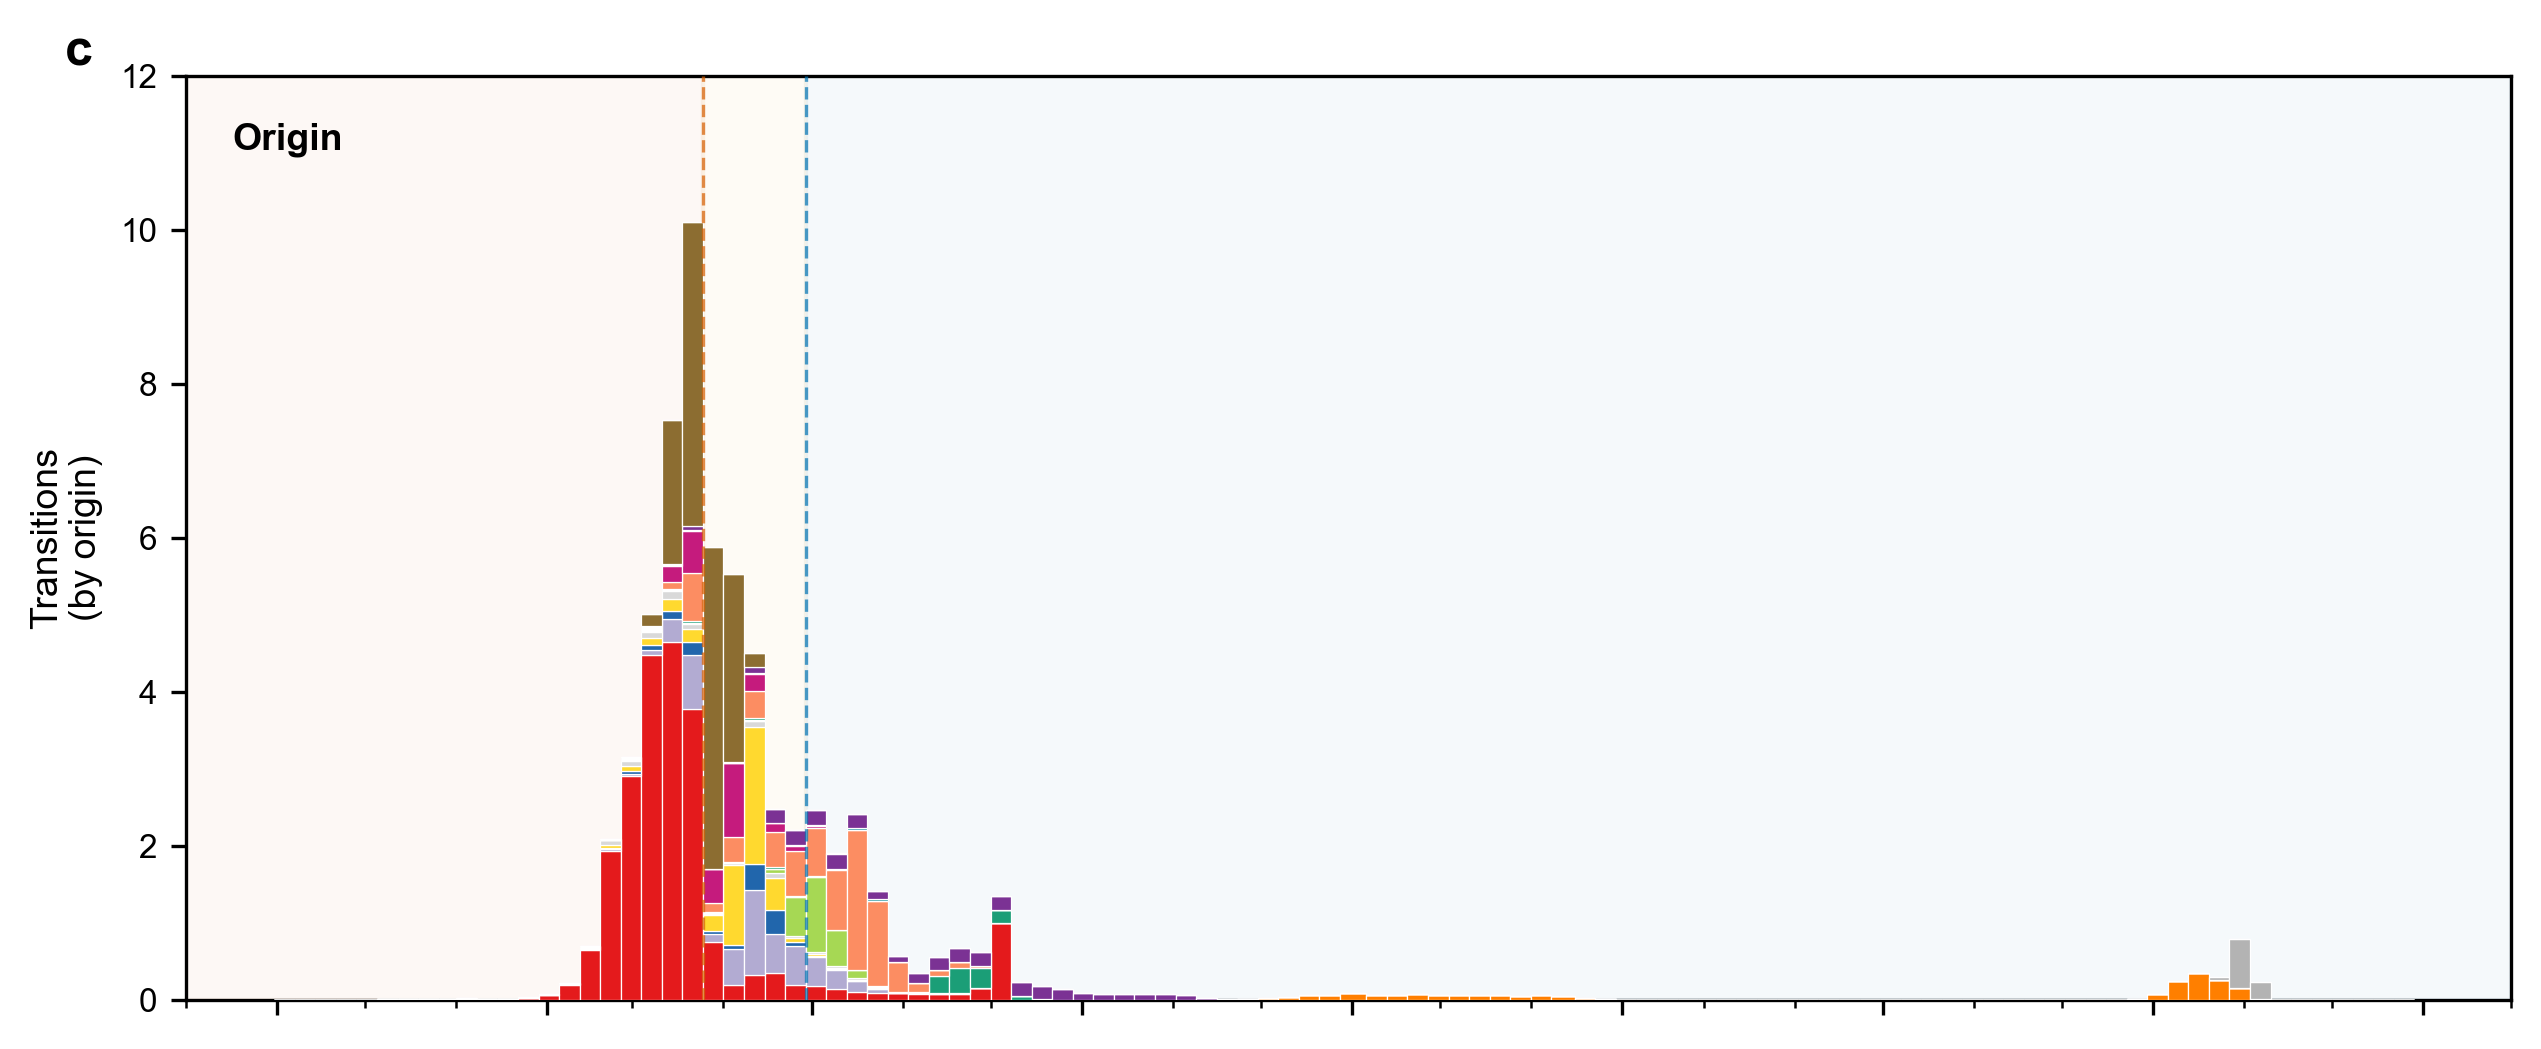

In [6]:
def _transition_ylim():
    left_edges, widths, origin_counts, dest_counts, states_ordered = load_posterior_transitions()
    orig_total = sum(origin_counts[s] for s in states_ordered)
    dest_total = sum(dest_counts[s] for s in states_ordered)
    peak = max(max(orig_total), max(dest_total))
    return 0, np.ceil(peak * 1.15)


def draw_panel_C(ax, label="c"):
    _panel_label(ax, label)
    left_edges, widths, origin_counts, _, states_ordered = load_posterior_transitions()

    bottom = np.zeros(len(left_edges))

    for state in states_ordered:
        vals = origin_counts[state]
        color = TREE_STATE_COLORS.get(state, "#aaaaaa")
        ax.bar(left_edges, vals, width=[timedelta(days=w) for w in widths],
               bottom=bottom, color=color, edgecolor="white", linewidth=0.3, label=state,
               align="edge", zorder=3)
        bottom += vals

    ax.set_ylabel("Transitions\n(by origin)")
    ax.set_ylim(*_transition_ylim())
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    _add_era_shading(ax)
    _add_vlines(ax)
    _format_time_axis(ax, show_labels=False)

    ax.text(0.02, 0.95, "Origin", transform=ax.transAxes, fontsize=9,
            fontweight="bold", ha="left", va="top")


def draw_panel_D(ax, label="d"):
    _panel_label(ax, label)
    left_edges, widths, _, dest_counts, states_ordered = load_posterior_transitions()

    bottom = np.zeros(len(left_edges))

    for state in states_ordered:
        vals = dest_counts[state]
        color = TREE_STATE_COLORS.get(state, "#aaaaaa")
        ax.bar(left_edges, vals, width=[timedelta(days=w) for w in widths],
               bottom=bottom, color=color, edgecolor="white", linewidth=0.3, label=state,
               align="edge", zorder=3)
        bottom += vals

    ax.set_ylabel("Transitions\n(by dest.)")
    ax.set_ylim(*_transition_ylim())
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    _add_era_shading(ax)
    _add_vlines(ax)
    _format_time_axis(ax, show_labels=False)

    ax.text(0.02, 0.95, "Destination", transform=ax.transAxes, fontsize=9,
            fontweight="bold", ha="left", va="top")


fig_c, ax_c = plt.subplots(figsize=(10, 4))
draw_panel_C(ax_c)
_format_time_axis(ax_c, show_labels=True)
plt.show()

/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_91587/4245471416.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wahis["WAHIS_date"] = pd.to_datetime(wahis["WAHIS_start_date"])#, format="%m/%d/%Y", errors="coerce")


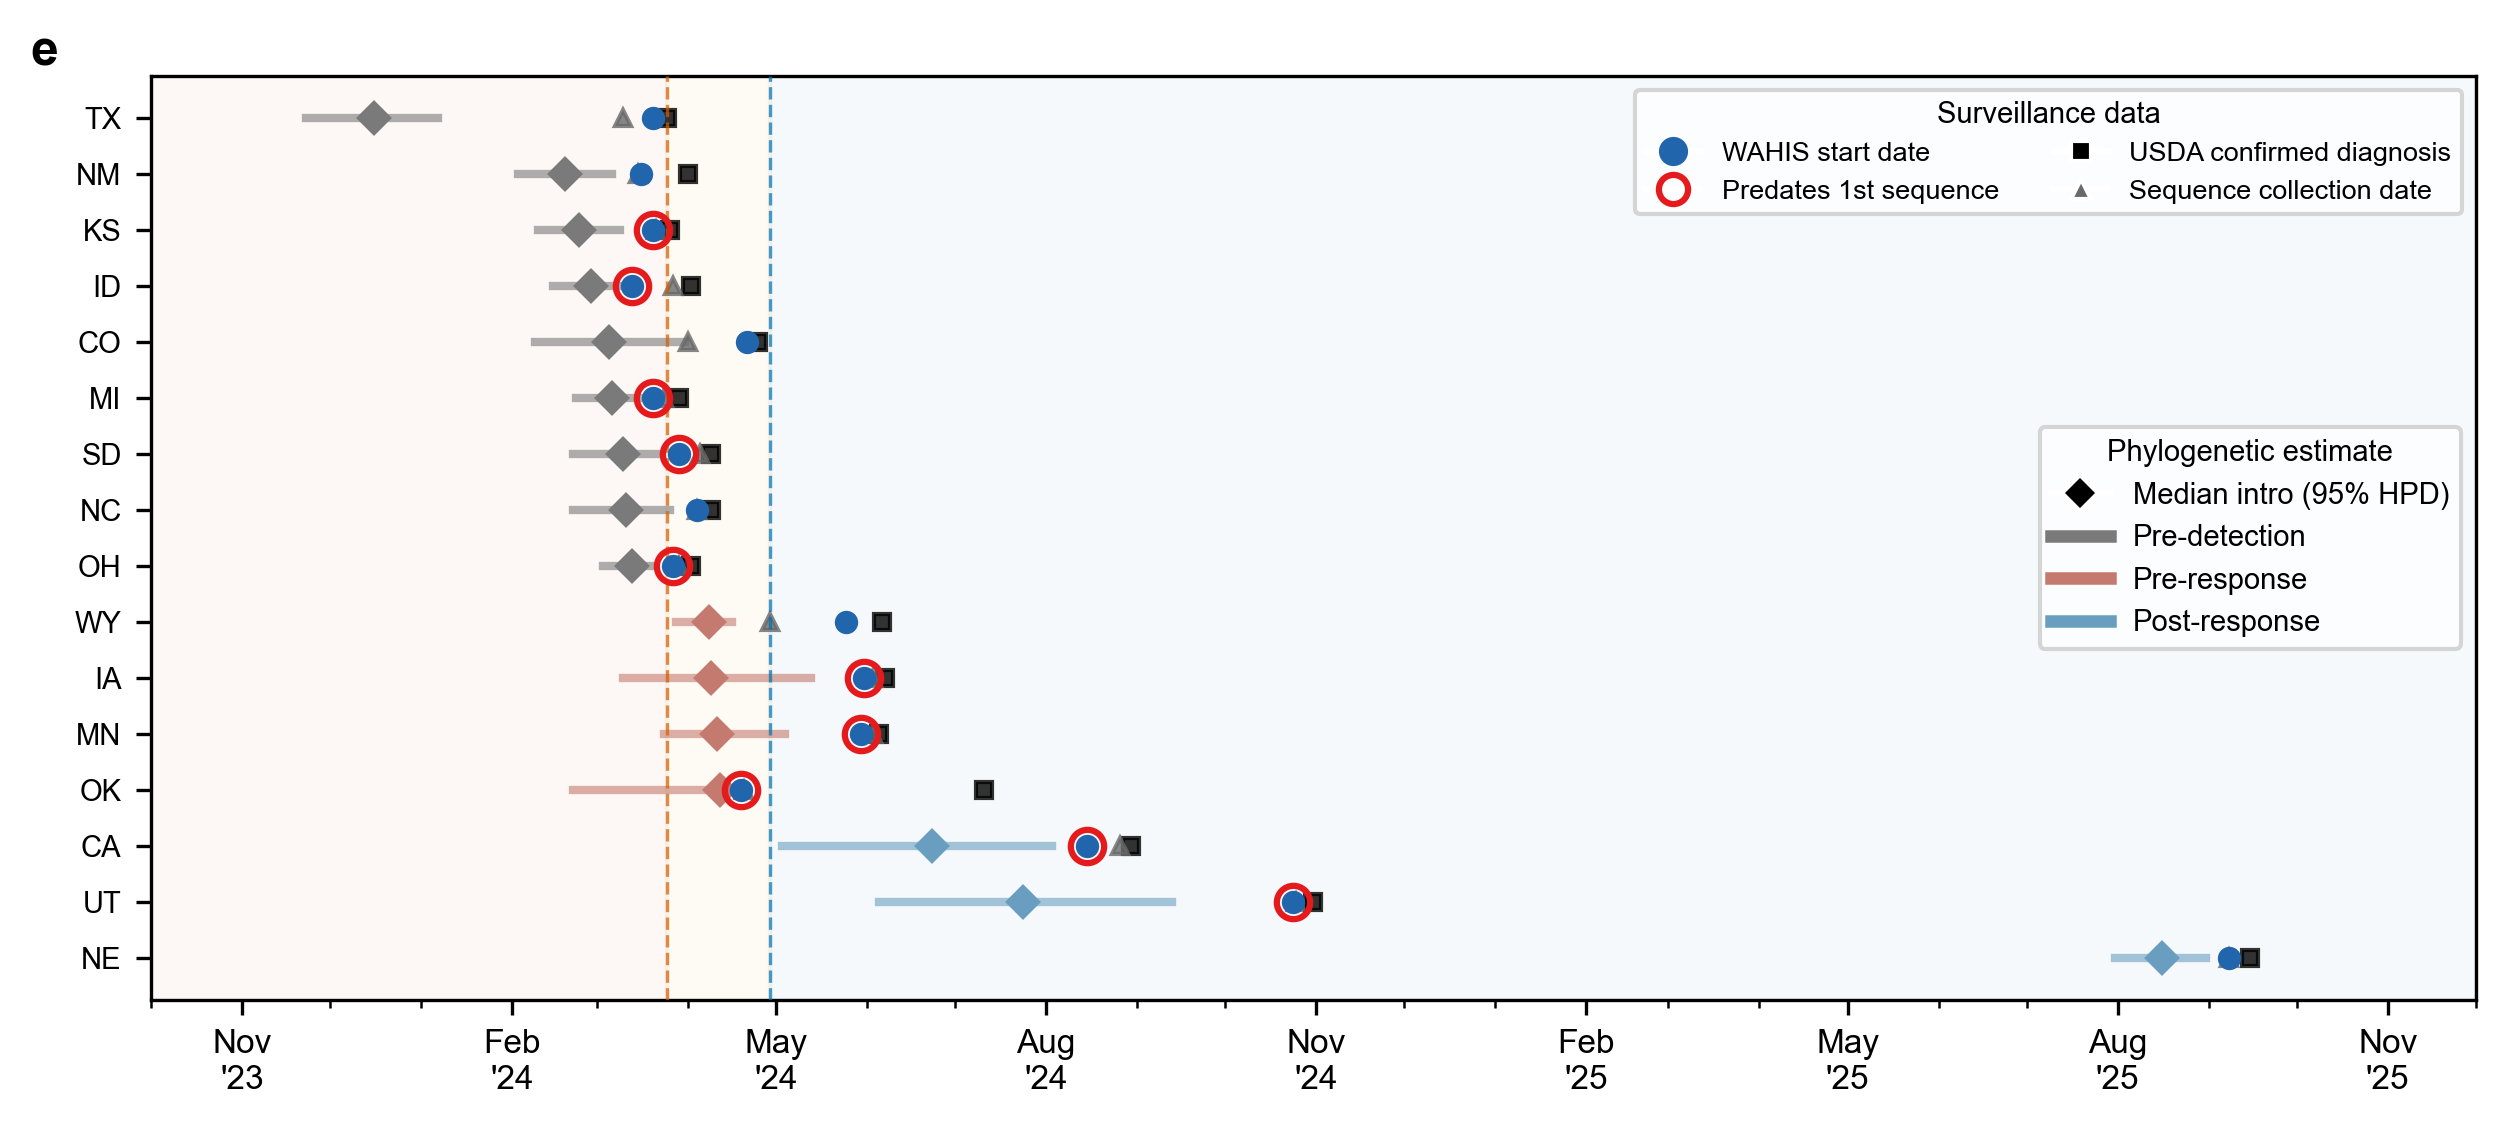

In [7]:
def _load_wahis_dates():
    """Load WAHIS outbreak start dates only (USDA dates come from our intro timing table)."""
    wahis = pd.read_csv(WAHIS_CSV)
    wahis["WAHIS_date"] = pd.to_datetime(wahis["WAHIS_start_date"])#, format="%m/%d/%Y", errors="coerce")
    wahis["abbrev"] = wahis["State"].map(STATE_ABBREV)
    result = {}
    for _, row in wahis.iterrows():
        if pd.notna(row["abbrev"]) and pd.notna(row["WAHIS_date"]):
            result[row["abbrev"]] = row["WAHIS_date"]
    return result


def draw_panel_E(ax, label="e"):
    _panel_label(ax, label)
    df = load_intro_timing()

    df = df.sort_values("Median intro (date)", ascending=True).reset_index(drop=True)
    y_pos = np.arange(len(df))

    wahis = _load_wahis_dates()

    for i, row in df.iterrows():
        med = row["Median intro (date)"]
        lo = row["95% HPD lower"]
        hi = row["95% HPD upper"]

        if med < TX_DETECT:
            col = '#7a7a7a'
        elif med < FED_ORDER:
            col = '#c47a6e'
        else:
            col = '#6a9ec0'

        ax.plot([lo, hi], [i, i], color=col, linewidth=2, alpha=0.6, zorder=2)
        ax.plot(med, i, "D", color=col, markersize=5, zorder=4)

    for i, row in df.iterrows():
        if pd.notna(row["Earliest outbreak"]):
            ax.plot(row["Earliest outbreak"], i, "s", color="black",
                    markersize=4, zorder=5, alpha=0.8)

    for i, row in df.iterrows():
        if pd.notna(row["Earliest genome"]):
            ax.plot(row["Earliest genome"], i, "^", color="dimgrey",
                    markersize=4, zorder=5, alpha=0.8)

    for i, row in df.iterrows():
        state = row["State"]
        if state in wahis:
            w_date = wahis[state]
            precedes_seq = pd.notna(row["Earliest genome"]) and w_date < row["Earliest genome"]
            ax.plot(w_date, i, "o", color="#2166ac", markersize=5,
                    zorder=6, markeredgecolor="#2166ac", markeredgewidth=0.6)
            if precedes_seq:
                ax.plot(w_date, i, "o", color="none", markersize=8,
                        zorder=7, markeredgecolor="#e41a1c", markeredgewidth=1.5)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(df["State"], fontsize=7)
    ax.invert_yaxis()

    _add_era_shading(ax)
    _add_vlines(ax)
    _format_time_axis(ax, show_labels=True)

    data_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#2166ac",
               markersize=6, markeredgecolor="#2166ac", label="WAHIS start date"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="none",
               markersize=7, markeredgecolor="#e41a1c", markeredgewidth=1.5,
               label="Predates 1st sequence"),
        Line2D([0], [0], marker="s", color="w", markerfacecolor="black",
               markersize=5, label="USDA confirmed diagnosis"),
        Line2D([0], [0], marker="^", color="w", markerfacecolor="dimgrey",
               markersize=5, label="Sequence collection date"),
    ]
    leg1 = ax.legend(handles=data_elements, loc="upper right", fontsize=6.5,
                     framealpha=0.8, ncol=2, title="Surveillance data",
                     title_fontsize=7)
    ax.add_artist(leg1)

    era_elements = [
        Line2D([0], [0], marker="D", color="w", markerfacecolor="black",
               markersize=6, label="Median intro (95% HPD)"),
        Line2D([0], [0], color='#7a7a7a', linewidth=3, label="Pre-detection"),
        Line2D([0], [0], color='#c47a6e', linewidth=3, label="Pre-response"),
        Line2D([0], [0], color='#6a9ec0', linewidth=3, label="Post-response"),
    ]
    ax.legend(handles=era_elements, loc="center right", fontsize=7,
              framealpha=0.8, title="Phylogenetic estimate",
              title_fontsize=7)


fig_e, ax_e = plt.subplots(figsize=(10, 4))
draw_panel_E(ax_e)
plt.show()

## Combined Figure 2 (A-E)

/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_91587/1865403043.py:61: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect, connectors = ax.indicate_inset_zoom(inset, edgecolor="grey", alpha=0.6,
/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_91587/4245471416.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wahis["WAHIS_date"] = pd.to_datetime(wahis["WAHIS_start_date"])#, format="%m/%d/%Y", errors="coerce")


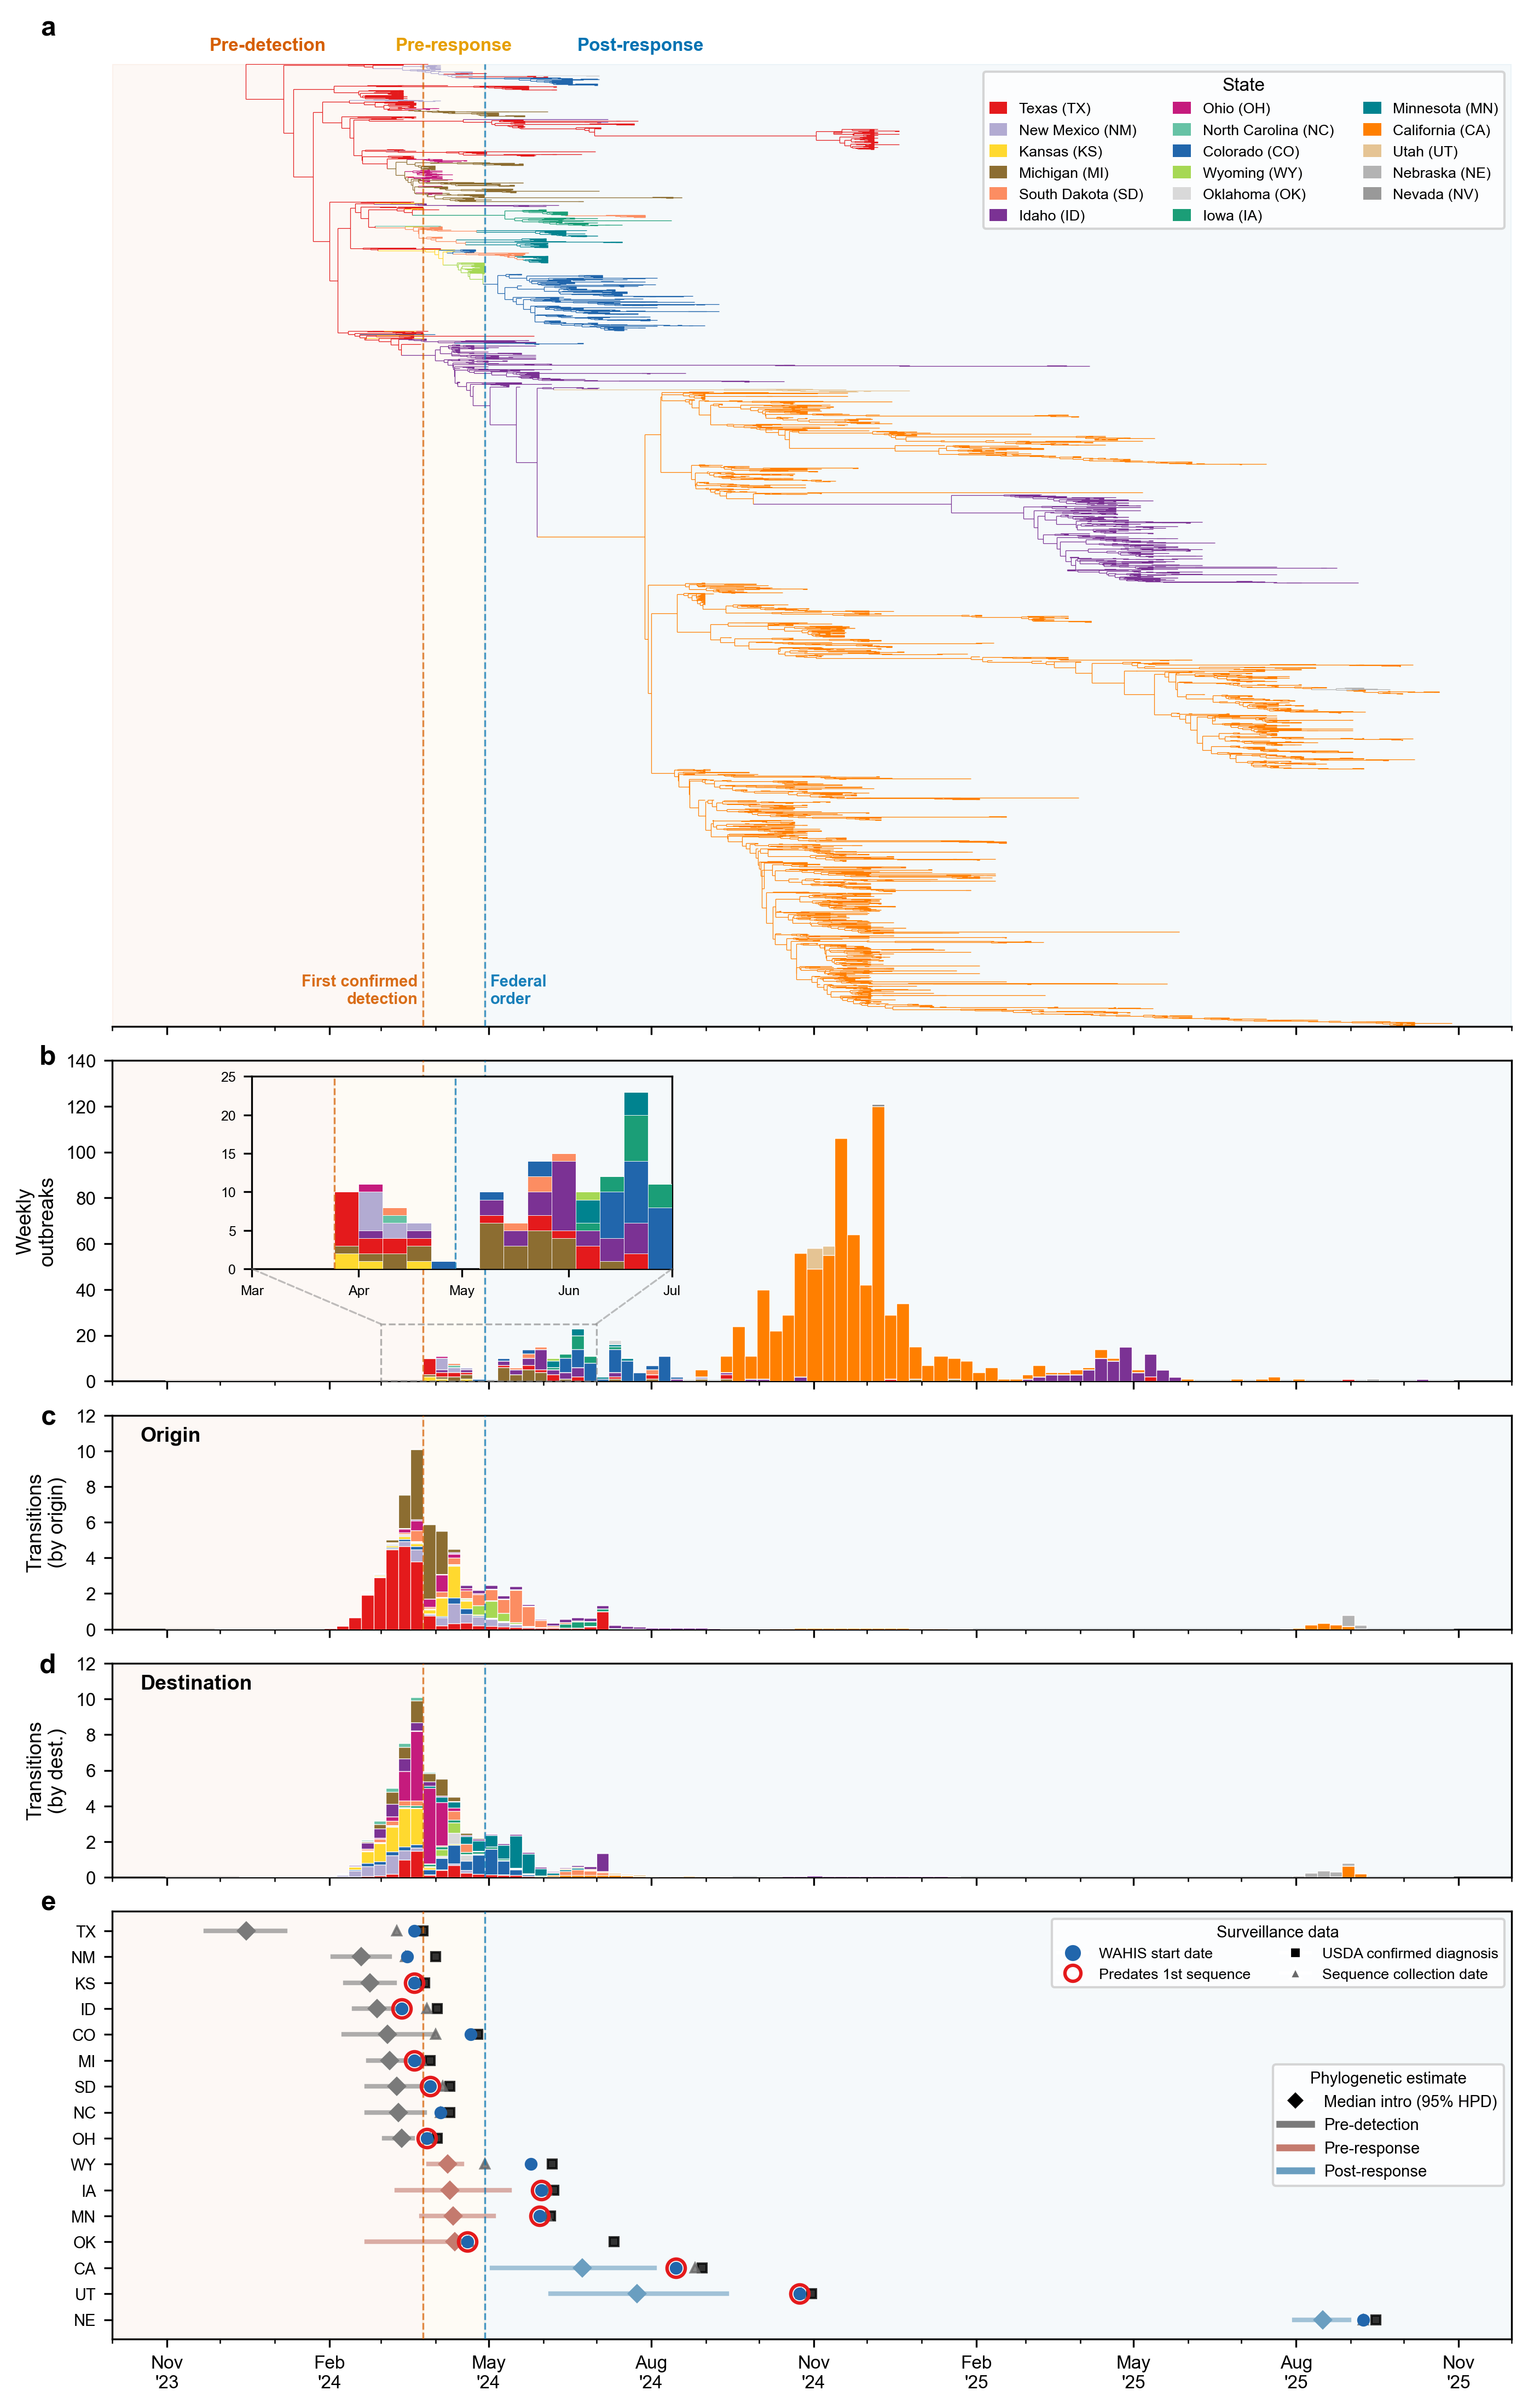

In [ ]:
fig = plt.figure(figsize=(11, 18))
gs = fig.add_gridspec(5, 1, height_ratios=[4.5, 1.5, 1.0, 1.0, 2.0],
                      hspace=0.08)

ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1], sharex=ax_a)
ax_c = fig.add_subplot(gs[2], sharex=ax_a)
ax_d = fig.add_subplot(gs[3], sharex=ax_a)
ax_e = fig.add_subplot(gs[4], sharex=ax_a)

draw_panel_A(ax_a)
draw_panel_B(ax_b)
draw_panel_C(ax_c)
draw_panel_D(ax_d)
draw_panel_E(ax_e)

# fig.savefig(FIG_DIR / "fig2.png", dpi=300, bbox_inches="tight")
# fig.savefig(FIG_DIR / "fig2.pdf", bbox_inches="tight")
# print(f"Saved fig2.png / .pdf to {FIG_DIR}")
plt.show()

## Summary statistics

In [9]:
# States per era: documented cases vs phylogenetic introductions

df_epi = load_epi_data()
df_epi = df_epi.dropna(subset=["date"]).copy()

state_first_case = df_epi.groupby("State")["date"].min().reset_index()
state_first_case.columns = ["State", "First case"]
state_first_case["Era"] = state_first_case["First case"].apply(assign_era)

era_counts = state_first_case.groupby("Era").size().reindex(
    ["Pre-detection", "Pre-response", "Post-response"], fill_value=0)
cumulative_epi = era_counts.cumsum()

print("=== Documented cases (epi data) ===")
for era in ["Pre-detection", "Pre-response", "Post-response"]:
    states = sorted(state_first_case[state_first_case["Era"] == era]["State"].tolist())
    print(f"  {era}: {era_counts[era]} new ({cumulative_epi[era]} cumulative) "
          f"\u2014 {', '.join(states) if states else 'none'}")

# Phylogenetic introductions
samples = load_jump_history()
era_names = ["Pre-detection", "Pre-response", "Post-response"]
phylo_states_per_era = {era: [] for era in era_names}

for sample_jumps in samples:
    states_by_era = {"Pre-detection": set(["TX"]), "Pre-response": set(), "Post-response": set()}
    for cal_date, src, dest in sample_jumps:
        era = assign_era(cal_date)
        states_by_era[era].add(dest)
        states_by_era[era].add(src)
    cumul = set()
    for era in era_names:
        cumul = cumul | states_by_era[era]
        phylo_states_per_era[era].append(len(cumul))

print("\n=== Phylogenetic introductions (posterior summary) ===")
rows = []
for era in era_names:
    arr = np.array(phylo_states_per_era[era])
    med = np.median(arr)
    lo, hi = hpd(arr)
    print(f"  {era}: median {med:.0f} states [{lo:.0f}, {hi:.0f}]")
    rows.append({
        "Era": era,
        "Documented (new)": era_counts[era],
        "Documented (cumulative)": cumulative_epi[era],
        "Phylo median states": med,
        "Phylo 95% HPD lower": lo,
        "Phylo 95% HPD upper": hi,
    })

# States in >50% of posterior samples per era
print("\n=== States present in >50% of posterior samples by end of era ===")
cumul_states_per_sample = {era: [] for era in era_names}
for sample_jumps in samples:
    states_by_era = {"Pre-detection": set(["TX"]), "Pre-response": set(), "Post-response": set()}
    for cal_date, src, dest in sample_jumps:
        era = assign_era(cal_date)
        states_by_era[era].add(dest)
        states_by_era[era].add(src)
    cumul = set()
    for era in era_names:
        cumul = cumul | states_by_era[era]
        cumul_states_per_sample[era].append(frozenset(cumul))

for era in era_names:
    state_freq = Counter()
    for s_set in cumul_states_per_sample[era]:
        for s in s_set:
            state_freq[s] += 1
    n = len(cumul_states_per_sample[era])
    common = sorted([s for s, c in state_freq.items() if c > n * 0.5],
                    key=lambda s: -state_freq[s])
    pcts = [f"{s} ({state_freq[s]/n*100:.0f}%)" for s in common]
    print(f"  {era}: {', '.join(pcts)}")

states_comparison = pd.DataFrame(rows)
# states_comparison.to_csv(TABLE_DIR / "states_per_era.csv", index=False)
# print(f"\nSaved to {TABLE_DIR / 'states_per_era.csv'}")

=== Documented cases (epi data) ===
  Pre-detection: 0 new (0 cumulative) — none
  Pre-response: 9 new (9 cumulative) — Colorado, Idaho, Kansas, Michigan, New Mexico, North Carolina, Ohio, South Dakota, Texas
  Post-response: 8 new (17 cumulative) — California, Iowa, Minnesota, Nebraska, Nevada, Oklahoma, Utah, Wyoming

=== Phylogenetic introductions (posterior summary) ===
  Pre-detection: median 9 states [8, 11]
  Pre-response: median 13 states [12, 14]
  Post-response: median 16 states [16, 16]

=== States present in >50% of posterior samples by end of era ===
  Pre-detection: OH (100%), TX (100%), NM (100%), KS (100%), ID (100%), MI (100%), SD (100%), NC (94%), CO (88%)
  Pre-response: CO (100%), OH (100%), OK (100%), TX (100%), NM (100%), KS (100%), NC (100%), SD (100%), ID (100%), WY (100%), MI (100%), MN (94%), IA (83%)
  Post-response: IA (100%), CO (100%), MN (100%), OK (100%), NM (100%), SD (100%), WY (100%), MI (100%), OH (100%), TX (100%), KS (100%), NC (100%), NE (100%), U

In [10]:
# Interstate transitions per era (posterior summary)
samples = load_jump_history()

era_transitions_per_sample = {"Pre-detection": [], "Pre-response": [], "Post-response": []}

for sample_jumps in samples:
    counts = {"Pre-detection": 0, "Pre-response": 0, "Post-response": 0}
    for cal_date, src, dest in sample_jumps:
        era = assign_era(cal_date)
        counts[era] += 1
    for era in counts:
        era_transitions_per_sample[era].append(counts[era])

rows = []
total_per_sample = np.zeros(len(samples))
for era in ["Pre-detection", "Pre-response", "Post-response"]:
    arr = np.array(era_transitions_per_sample[era])
    lo, hi = hpd(arr)
    rows.append({
        "Era": era,
        "Median transitions": np.median(arr),
        "Mean transitions": f"{np.mean(arr):.1f}",
        "95% HPD lower": lo,
        "95% HPD upper": hi,
    })
    total_per_sample += arr

lo_tot, hi_tot = hpd(total_per_sample)
rows.append({
    "Era": "Total",
    "Median transitions": np.median(total_per_sample),
    "Mean transitions": f"{np.mean(total_per_sample):.1f}",
    "95% HPD lower": lo_tot,
    "95% HPD upper": hi_tot,
})

transitions_per_era = pd.DataFrame(rows)
print("Interstate transitions per era (posterior summary):")
print(transitions_per_era.to_string(index=False))

cryptic_arr = np.array(era_transitions_per_sample["Pre-detection"])
expansion_arr = np.array(era_transitions_per_sample["Pre-response"])
postorder_arr = np.array(era_transitions_per_sample["Post-response"])
pre_order_arr = cryptic_arr + expansion_arr
pct_pre_detect = cryptic_arr / total_per_sample * 100
pct_pre_order = pre_order_arr / total_per_sample * 100
pct_postorder = postorder_arr / total_per_sample * 100
lo_d, hi_d = hpd(pct_pre_detect)
lo_o, hi_o = hpd(pct_pre_order)
lo_p, hi_p = hpd(pct_postorder)
print(f"\n% pre-detection: median {np.median(pct_pre_detect):.1f}% "
      f"[{lo_d:.1f}, {hi_d:.1f}]")
print(f"% pre-order: median {np.median(pct_pre_order):.1f}% "
      f"[{lo_o:.1f}, {hi_o:.1f}]")
print(f"% post-order: median {np.median(pct_postorder):.1f}% "
      f"[{lo_p:.1f}, {hi_p:.1f}]")

# transitions_per_era.to_csv(TABLE_DIR / "transitions_per_era.csv", index=False)
# print(f"\nSaved to {TABLE_DIR / 'transitions_per_era.csv'}")

Interstate transitions per era (posterior summary):
          Era  Median transitions Mean transitions  95% HPD lower  95% HPD upper
Pre-detection                29.0             29.1           23.0           35.0
 Pre-response                21.0             20.6           15.0           26.0
Post-response                16.0             16.4           12.0           21.0
        Total                66.0             66.1           59.0           74.0

% pre-detection: median 43.8% [36.8, 50.8]
% pre-order: median 75.4% [68.6, 81.6]
% post-order: median 24.6% [18.4, 31.4]


# What about two months post-order?

In [11]:
# Interstate transitions 2 months after postorder
d2months = datetime(2024, 6, 29)

transitions_per_sample = []
total_per_sample = []
for sample in samples:
    count = 0
    for cal_date, src, dest in sample:
        # if the date is more than 2 months after the postorder date
        if cal_date > d2months:
            count += 1
    transitions_per_sample.append(count)
    total_per_sample.append(len(sample))
    

arr = np.array(transitions_per_sample)
total_per_sample = np.array(total_per_sample)

lo, hi = hpd(arr)
print(f"Interstate transitions per sample (posterior summary): median {np.median(arr)}, mean {np.mean(arr):.1f}, 95% HPD [{lo:.1f}, {hi:.1f}]")

pct = arr / total_per_sample * 100  
lo_pct, hi_pct = hpd(pct)
print(f"% transitions per sample (posterior summary): median {np.median(pct):.1f}% "
      f"[{lo_pct:.1f}, {hi_pct:.1f}]")

Interstate transitions per sample (posterior summary): median 6.0, mean 5.6, 95% HPD [4.0, 7.0]
% transitions per sample (posterior summary): median 8.5% [5.6, 11.1]


---
## Supplementary figures

### S_TransitionPeak — KDE peak timing of interstate transmissions

Computing KDE peaks (σ=7d) for 90001 samples...
  5000/90001
  10000/90001
  15000/90001
  20000/90001
  25000/90001
  30000/90001
  35000/90001
  40000/90001
  45000/90001
  50000/90001
  55000/90001
  60000/90001
  65000/90001
  70000/90001
  75000/90001
  80000/90001
  85000/90001
  90000/90001

Peak transmission date:
  Median: 2024-03-20
  95% HPD: [2024-03-14, 2024-03-25]
  5 days before first detection
  40 days before federal order


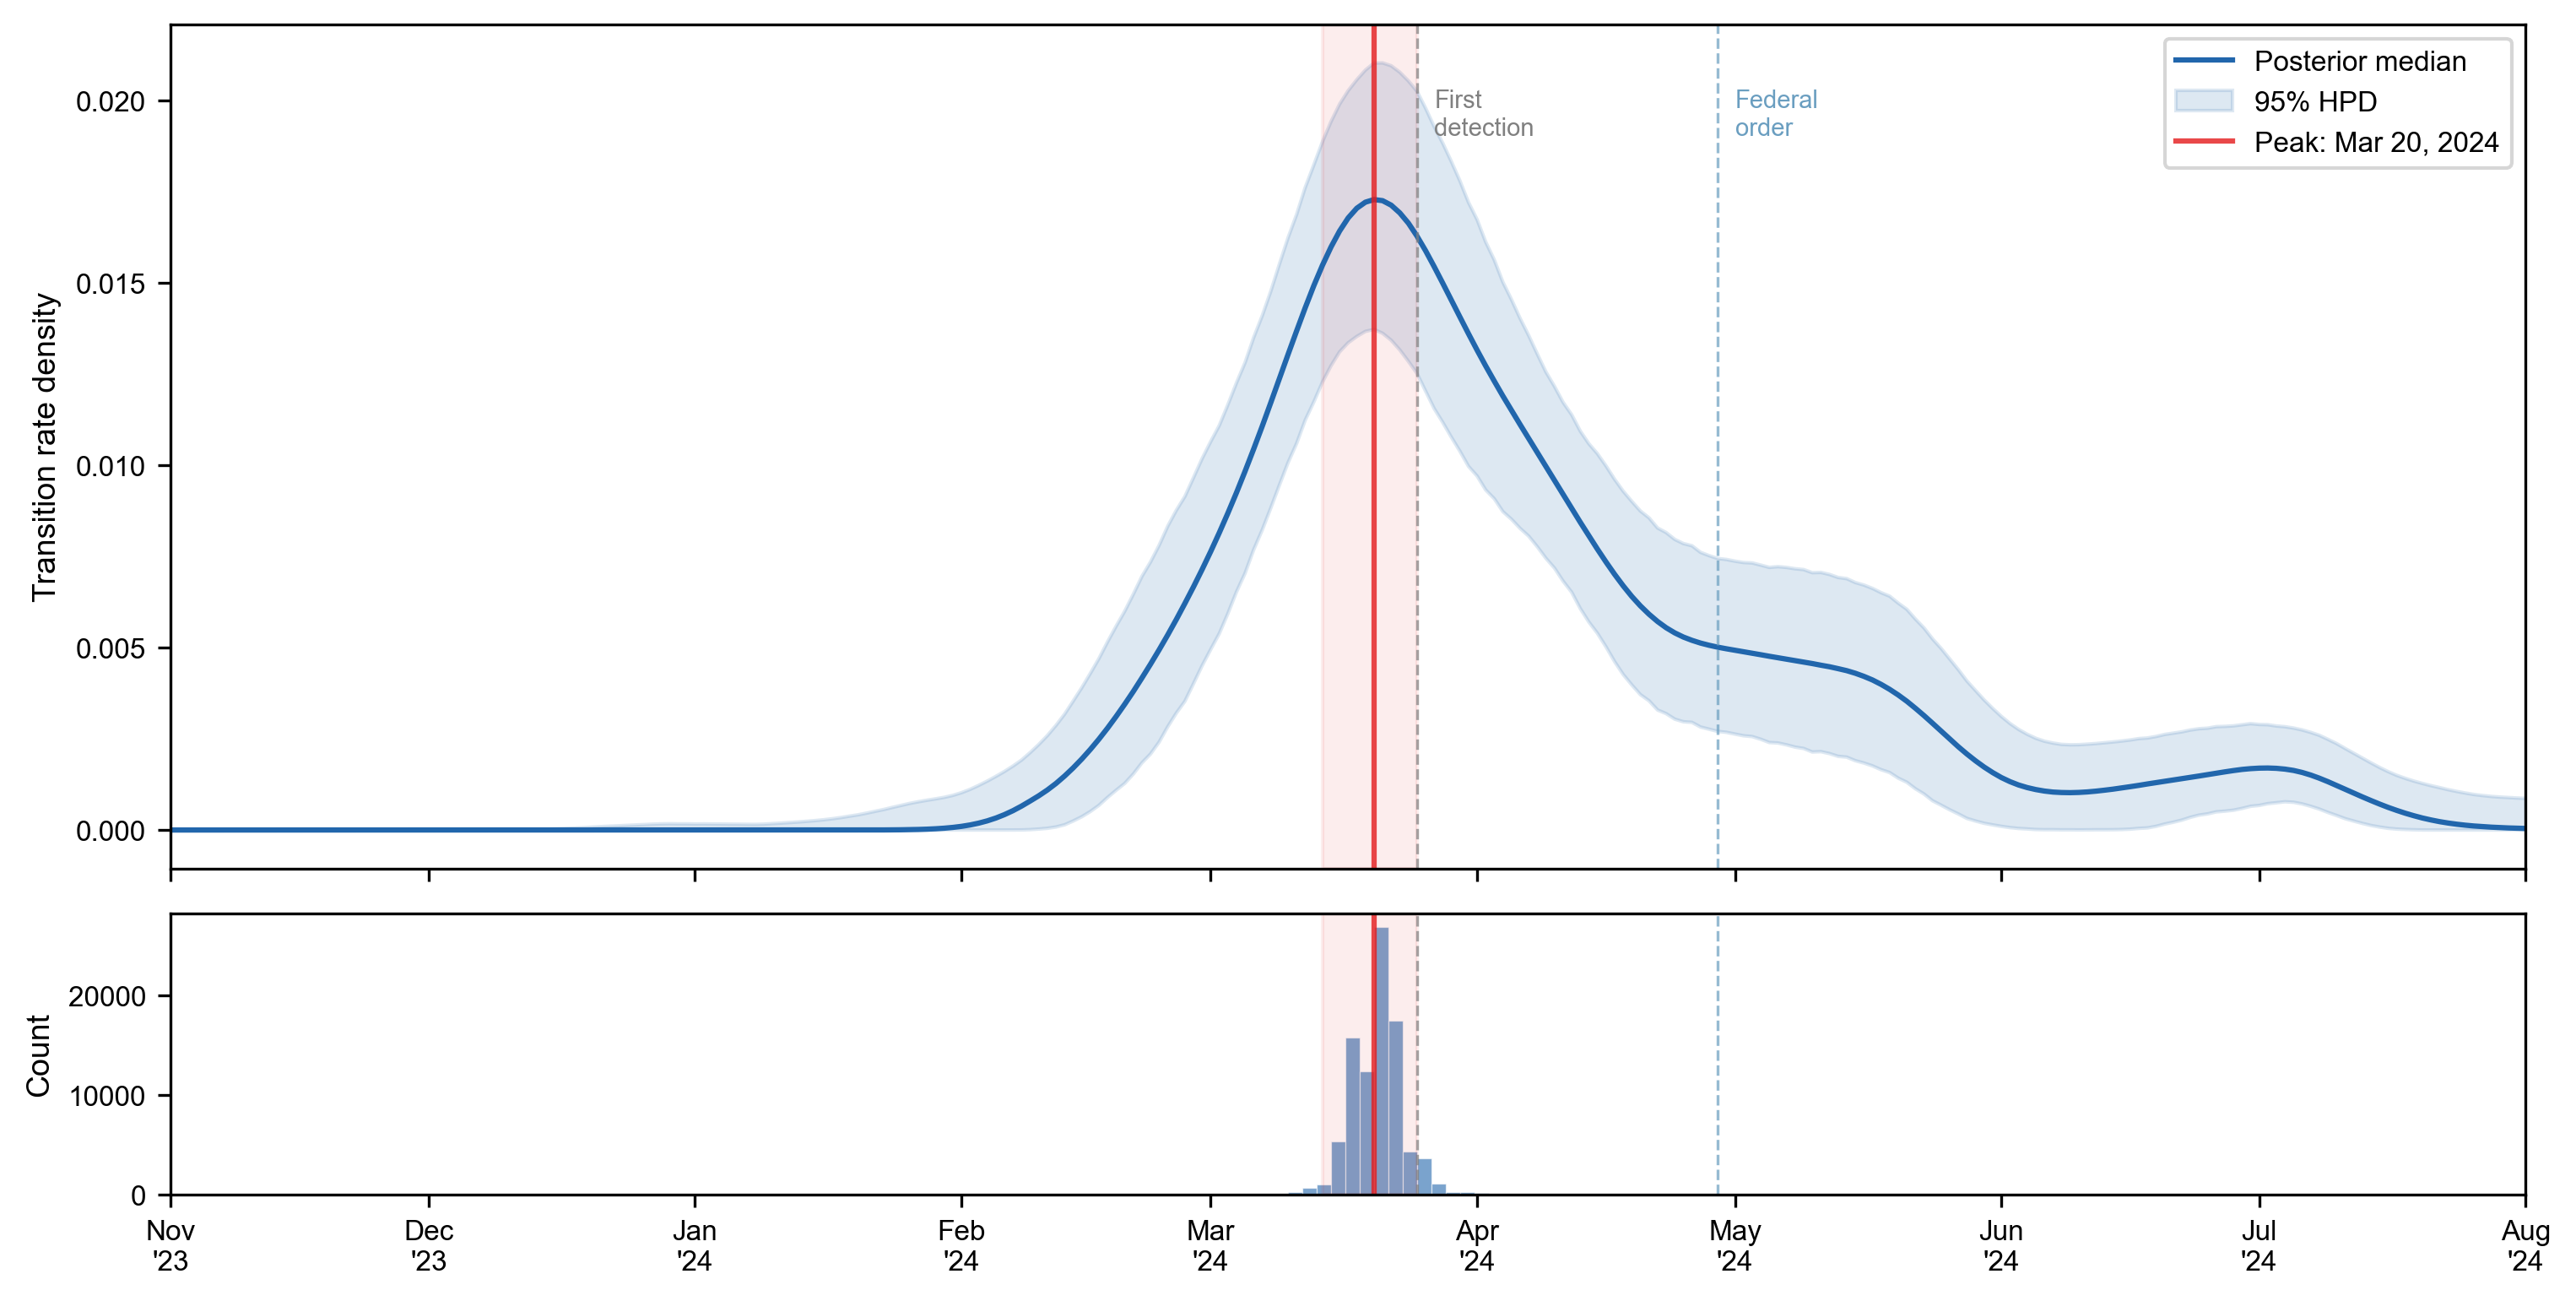

In [12]:
KDE_SIGMA_DAYS = 7

def date_to_numeric(dt):
    return (dt - datetime(2023, 1, 1)).total_seconds() / 86400

def numeric_to_date(n):
    return datetime(2023, 1, 1) + timedelta(days=n)

grid_start = date_to_numeric(datetime(2023, 11, 1))
grid_end = date_to_numeric(datetime(2025, 12, 1))
eval_grid = np.arange(grid_start, grid_end, 1.0)

samples = load_jump_history()
print(f'Computing KDE peaks (\u03c3={KDE_SIGMA_DAYS}d) for {len(samples)} samples...')
peak_dates_numeric = []
all_densities = []

for i, jumps in enumerate(samples):
    dates = [j[0] for j in jumps]
    if len(dates) < 2:
        continue
    numeric_dates = np.array([date_to_numeric(d) for d in dates])
    kde = gaussian_kde(numeric_dates, bw_method=KDE_SIGMA_DAYS / np.std(numeric_dates))
    density = kde(eval_grid)
    all_densities.append(density)
    peak_dates_numeric.append(eval_grid[np.argmax(density)])
    if (i + 1) % 5000 == 0:
        print(f'  {i+1}/{len(samples)}')

peak_dates_numeric = np.array(peak_dates_numeric)
all_densities = np.array(all_densities)

lo_peak, hi_peak = hpd(peak_dates_numeric)
median_peak = np.median(peak_dates_numeric)
median_date = numeric_to_date(median_peak)
lo_date = numeric_to_date(lo_peak)
hi_date = numeric_to_date(hi_peak)

print(f'\nPeak transmission date:')
print(f'  Median: {median_date.strftime("%Y-%m-%d")}')
print(f'  95% HPD: [{lo_date.strftime("%Y-%m-%d")}, {hi_date.strftime("%Y-%m-%d")}]')
print(f'  {(TX_DETECT - median_date).days} days before first detection')
print(f'  {(FED_ORDER - median_date).days} days before federal order')

grid_dates = [numeric_to_date(g) for g in eval_grid]
median_density = np.median(all_densities, axis=0)
lo_density = np.zeros(len(eval_grid))
hi_density = np.zeros(len(eval_grid))
for gi in range(len(eval_grid)):
    lo_density[gi], hi_density[gi] = hpd(all_densities[:, gi])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), height_ratios=[3, 1],
                                sharex=True, gridspec_kw={'hspace': 0.08})

ax1.plot(grid_dates, median_density, color='#2166ac', lw=1.5, label='Posterior median')
ax1.fill_between(grid_dates, lo_density, hi_density, color='#2166ac', alpha=0.15, label='95% HPD')
ax1.axvline(median_date, color='#e41a1c', lw=1.5, alpha=0.8,
            label=f'Peak: {median_date.strftime("%b %d, %Y")}')
ax1.axvspan(lo_date, hi_date, color='#e41a1c', alpha=0.08)
ax1.axvline(TX_DETECT, color='grey', lw=0.8, ls='--', alpha=0.7)
ax1.axvline(FED_ORDER, color='#6a9ec0', lw=0.8, ls='--', alpha=0.7)
ax1.text(TX_DETECT + timedelta(days=2), ax1.get_ylim()[1] * 0.92,
         'First\ndetection', fontsize=7, ha='left', va='top', color='grey')
ax1.text(FED_ORDER + timedelta(days=2), ax1.get_ylim()[1] * 0.92,
         'Federal\norder', fontsize=7, ha='left', va='top', color='#6a9ec0')
ax1.set_ylabel('Transition rate density')
ax1.legend(loc='upper right', fontsize=8)

peak_dates_dt = [numeric_to_date(p) for p in peak_dates_numeric]
ax2.hist(peak_dates_dt, bins=30, color='#2166ac', alpha=0.6, edgecolor='white', lw=0.3)
ax2.axvline(median_date, color='#e41a1c', lw=1.5, alpha=0.8)
ax2.axvspan(lo_date, hi_date, color='#e41a1c', alpha=0.08)
ax2.axvline(TX_DETECT, color='grey', lw=0.8, ls='--', alpha=0.7)
ax2.axvline(FED_ORDER, color='#6a9ec0', lw=0.8, ls='--', alpha=0.7)
ax2.set_ylabel('Count')
# ax2.set_xlabel('Date')
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b\n'%y"))
ax1.set_xlim(datetime(2023, 11, 1), datetime(2024, 8, 1))

# fig.savefig(FIG_DIR / 'S_TransitionPeak.png', bbox_inches='tight')
# fig.savefig(FIG_DIR / 'S_TransitionPeak.pdf', bbox_inches='tight')
# print(f'Saved S_TransitionPeak to {FIG_DIR}')
plt.show()

### S_AsymmetryCorrelateSet — Transmission asymmetry index

State    Asym    HPD_lo    HPD_hi    Exp    Imp
  NC  -1.000    -1.000    -1.000    0.0    1.0
  UT  -1.000    -1.000    -1.000    0.0    1.0
  MN  -1.000    -1.000    -0.750    0.0    7.0
  OK  -1.000    -1.000     0.273    0.0    1.0
  OH  -0.857    -1.000     0.538    1.0   13.0
  CO  -0.750    -1.000    -0.286    1.0    8.0
  ID  -0.333    -0.400    -0.200    3.0    6.0
  KS  -0.333    -0.800     0.077    4.0    7.0
  IA   0.000     0.000     0.000    1.0    1.0
  NE   0.000    -1.000     0.000    1.0    1.0
  NV   0.000     0.000     0.000    0.0    0.0
  CA   0.000     0.000     0.500    2.0    2.0
  NM   0.200    -0.333     0.333    5.0    3.0
  WY   0.333     0.000     0.538    2.0    1.0
  SD   0.400     0.143     0.600    8.0    3.0
  MI   0.600    -0.833     0.800   14.0    3.0
  TX   0.643     0.355     0.806   23.0    5.0


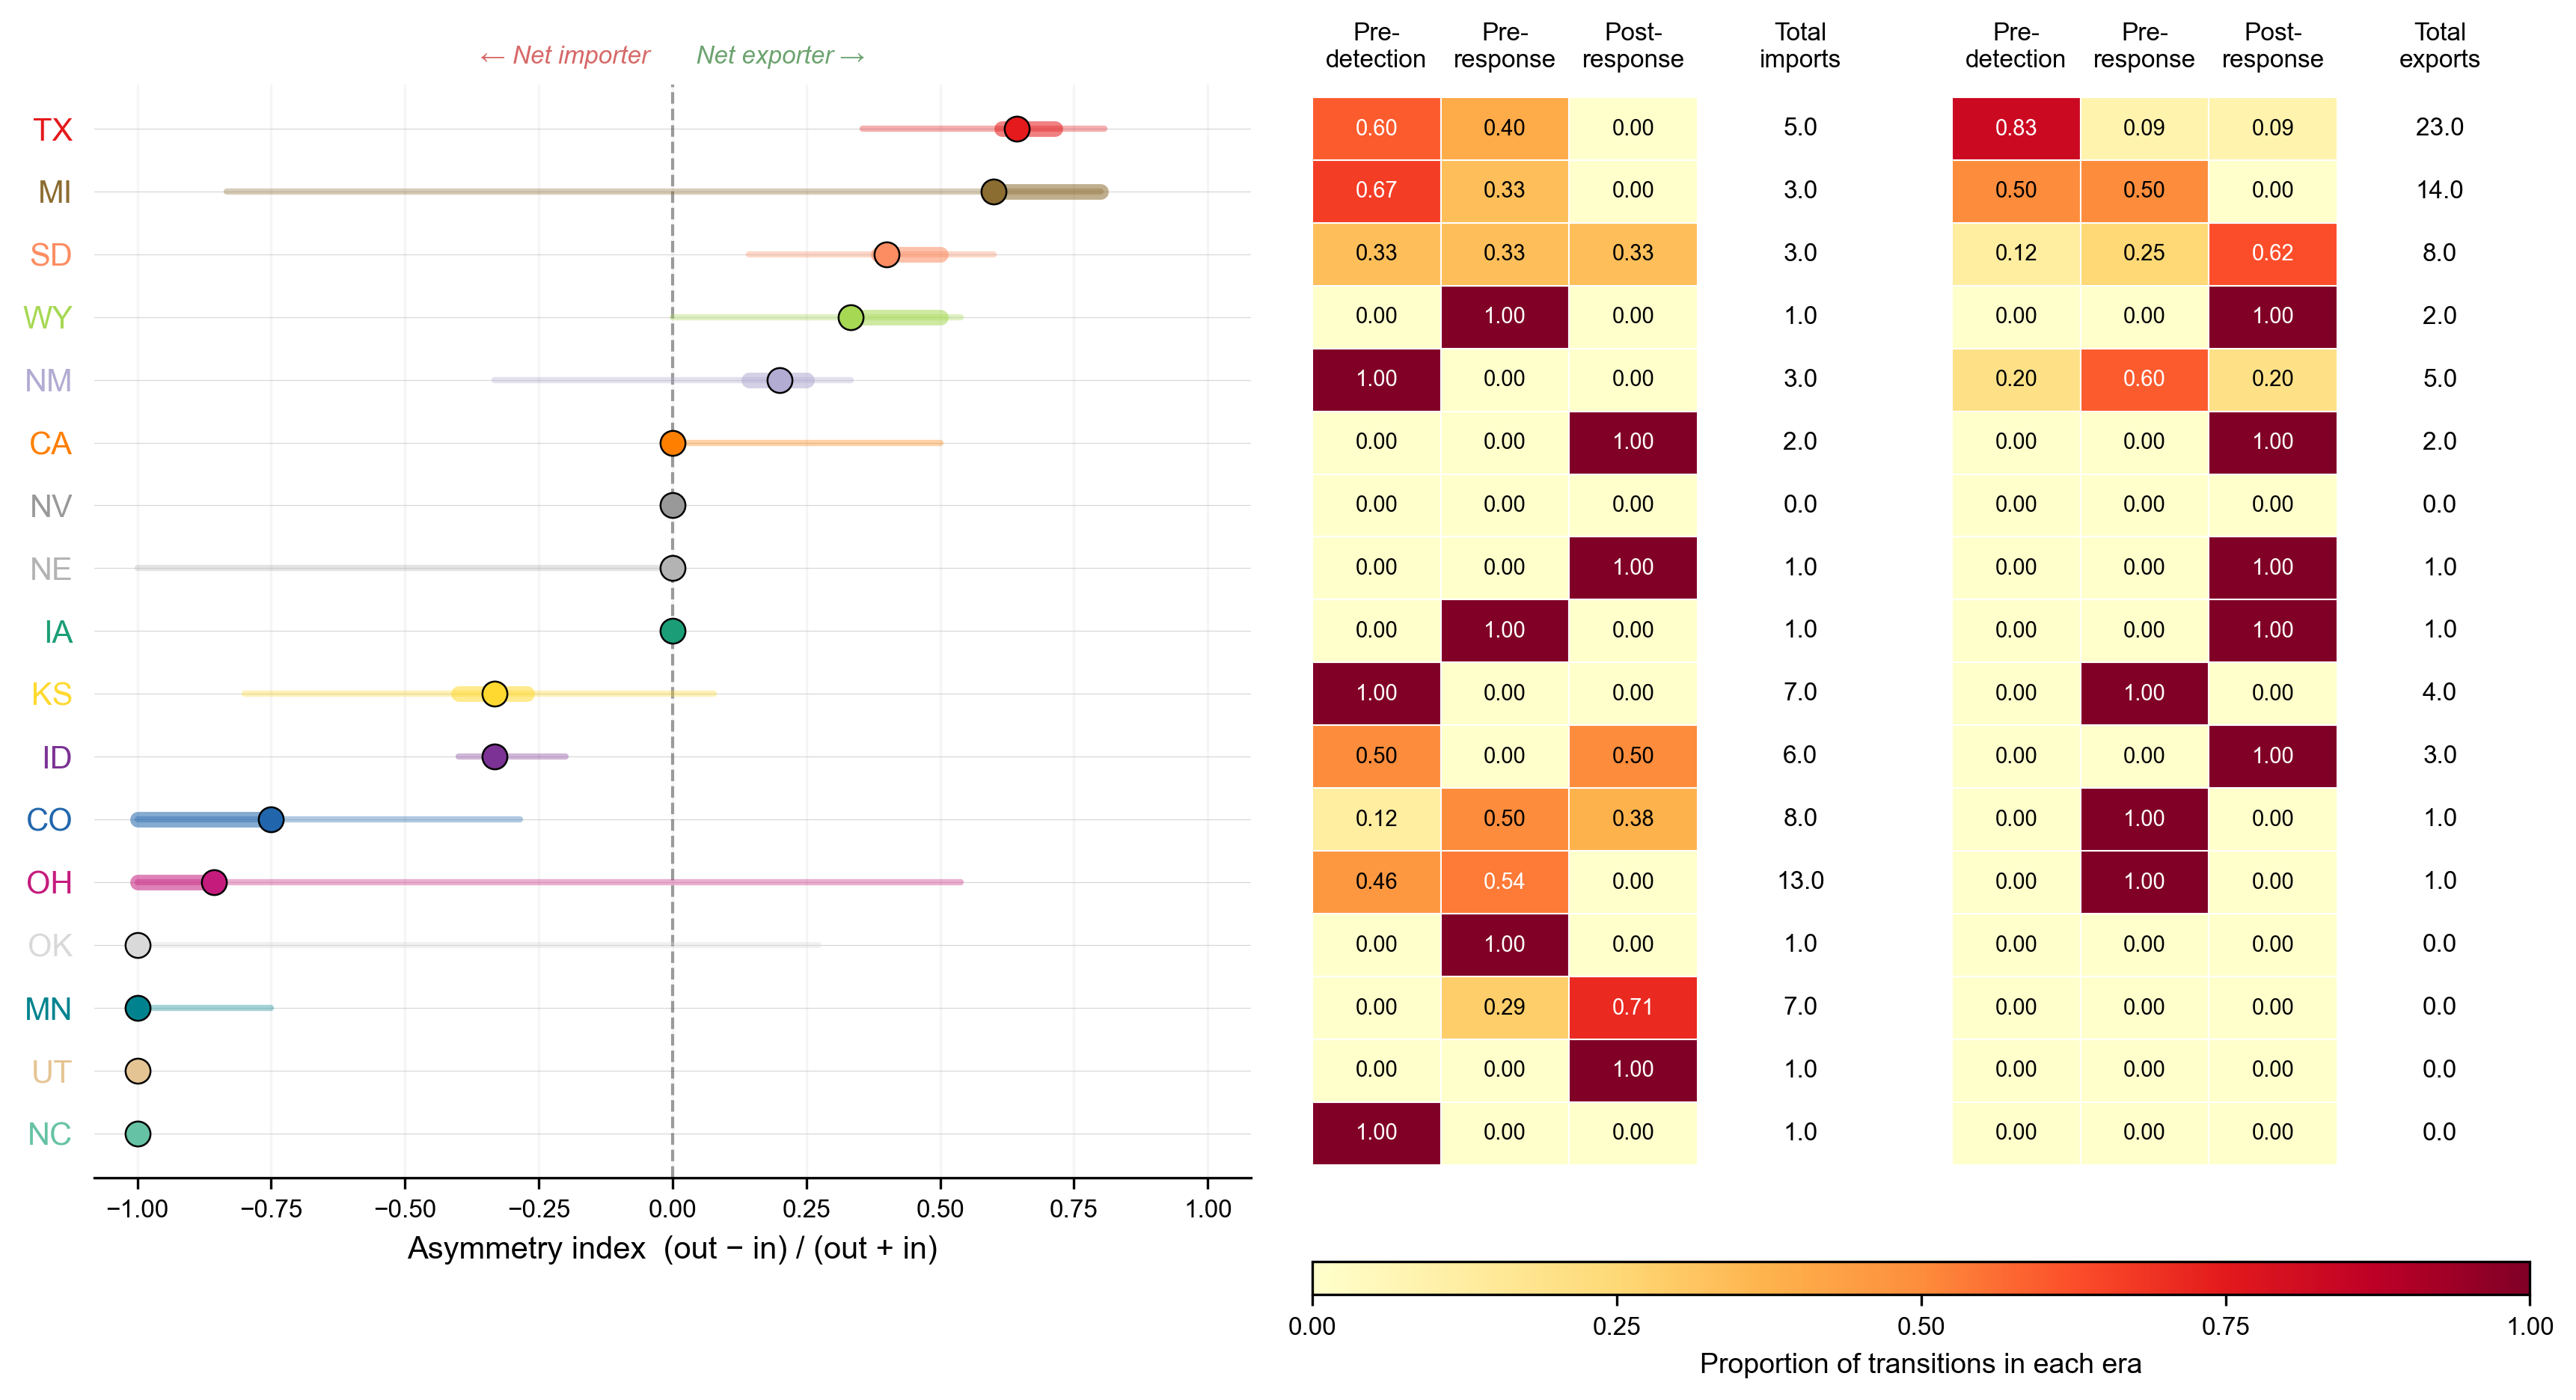

In [13]:
samples = load_jump_history()

asym = {s: [] for s in STATE_ORDER}
exports_by_era = {s: {'Pre-detection': [], 'Pre-response': [], 'Post-response': []} for s in STATE_ORDER}
imports_by_era = {s: {'Pre-detection': [], 'Pre-response': [], 'Post-response': []} for s in STATE_ORDER}

for jumps in samples:
    out = {s: 0 for s in STATE_ORDER}
    inc = {s: 0 for s in STATE_ORDER}
    out_era = {s: {'Pre-detection': 0, 'Pre-response': 0, 'Post-response': 0} for s in STATE_ORDER}
    in_era = {s: {'Pre-detection': 0, 'Pre-response': 0, 'Post-response': 0} for s in STATE_ORDER}
    for cal_date, src, dest in jumps:
        if src in out: out[src] += 1
        if dest in inc: inc[dest] += 1
        era = assign_era(cal_date)
        if src in out_era: out_era[src][era] += 1
        if dest in in_era: in_era[dest][era] += 1
    for s in STATE_ORDER:
        total = out[s] + inc[s]
        asym[s].append((out[s] - inc[s]) / total if total > 0 else 0.0)
        for era in ['Pre-detection', 'Pre-response', 'Post-response']:
            exports_by_era[s][era].append(out_era[s][era])
            imports_by_era[s][era].append(in_era[s][era])

asym = {s: np.array(v) for s, v in asym.items()}

sorted_states = sorted(STATE_ORDER,
                        key=lambda s: (np.median(asym[s]), hpd(asym[s])[1]))

era_list = ['Pre-detection', 'Pre-response', 'Post-response']
median_exports = {}
median_export_props = {}
median_imports = {}
median_import_props = {}
for s in sorted_states:
    exp_medians = [np.median(exports_by_era[s][era]) for era in era_list]
    imp_medians = [np.median(imports_by_era[s][era]) for era in era_list]
    total_exp = sum(exp_medians)
    total_imp = sum(imp_medians)
    median_exports[s] = total_exp
    median_imports[s] = total_imp
    median_export_props[s] = [m / total_exp for m in exp_medians] if total_exp > 0 else [0, 0, 0]
    median_import_props[s] = [m / total_imp for m in imp_medians] if total_imp > 0 else [0, 0, 0]

print(f'{"State":>4s}  {"Asym":>6s}  {"HPD_lo":>8s}  {"HPD_hi":>8s}  {"Exp":>5s}  {"Imp":>5s}')
for s in sorted_states:
    lo, hi = hpd(asym[s])
    print(f'{s:>4s}  {np.median(asym[s]):>6.3f}  {lo:>8.3f}  {hi:>8.3f}  {median_exports[s]:>5.1f}  {median_imports[s]:>5.1f}')

# Figure
cmap_prop = plt.cm.YlOrRd
norm = Normalize(vmin=0, vmax=1)

fig = plt.figure(figsize=(14, 7))
gs_asym = gridspec.GridSpec(2, 3, width_ratios=[4, 2, 2], height_ratios=[1, 0.03],
                            wspace=0.08, hspace=0.15)
ax_forest = fig.add_subplot(gs_asym[0, 0])
ax_imp = fig.add_subplot(gs_asym[0, 1])
ax_exp = fig.add_subplot(gs_asym[0, 2])
ax_cbar = fig.add_subplot(gs_asym[1, 1:])

n_s = len(sorted_states)
y_pos = np.arange(n_s)
ylim = (-0.7, n_s - 0.3)

for yi, s in enumerate(sorted_states):
    a = asym[s]
    med = np.median(a)
    lo, hi = hpd(a)
    q25, q75 = hpd(a, credible_mass=0.50)
    color = TREE_STATE_COLORS.get(s, '#aaa')

    ax_forest.axhline(yi, color='grey', lw=0.3, alpha=0.3, zorder=0)
    ax_forest.plot([lo, hi], [yi, yi], color=color, lw=2, alpha=0.35, zorder=2, solid_capstyle='round')
    ax_forest.plot([q25, q75], [yi, yi], color=color, lw=5, alpha=0.55, zorder=3, solid_capstyle='round')
    ax_forest.plot(med, yi, 'o', color=color, ms=8, zorder=4, markeredgecolor='black', markeredgewidth=0.6)

ax_forest.set_yticks(y_pos)
ax_forest.set_yticklabels(sorted_states, fontsize=10)
for tick_label, st in zip(ax_forest.get_yticklabels(), sorted_states):
    tick_label.set_color(TREE_STATE_COLORS.get(st, '#aaa'))

ax_forest.axvline(0, color='black', ls='--', lw=1, alpha=0.4, zorder=1)
ax_forest.set_xlim(-1.08, 1.08)
ax_forest.set_ylim(*ylim)
ax_forest.set_xlabel('Asymmetry index  (out − in) / (out + in)', fontsize=10)
ax_forest.grid(True, alpha=0.12, axis='x')
for sp in ['top', 'right', 'left']:
    ax_forest.spines[sp].set_visible(False)
ax_forest.tick_params(left=False)
ax_forest.text(0.52, 1.015, 'Net exporter →', transform=ax_forest.transAxes,
               fontsize=8, color='#2e7d32', ha='left', va='bottom', style='italic', alpha=0.7)
ax_forest.text(0.48, 1.015, '← Net importer', transform=ax_forest.transAxes,
               fontsize=8, color='#c62828', ha='right', va='bottom', style='italic', alpha=0.7)

def draw_prop_heatmap(ax, proportions, totals, header_label):
    for yi, s in enumerate(sorted_states):
        for ei, era in enumerate(era_list):
            val = proportions[s][ei]
            facecolor = cmap_prop(norm(val))
            rect = plt.Rectangle((ei - 0.5, yi - 0.5), 1, 1, facecolor=facecolor,
                                 edgecolor='white', lw=0.5)
            ax.add_patch(rect)
            textcolor = 'white' if val > 0.5 else 'black'
            ax.text(ei, yi, f'{val:.2f}', ha='center', va='center', fontsize=7, color=textcolor)
        ax.text(3.3, yi, f'{totals[s]:.1f}', ha='center', va='center', fontsize=8)

    ax.set_xlim(-0.5, 4.0)
    ax.set_ylim(*ylim)
    ax.set_xticks([])
    header_y = n_s - 0.1
    for ei, label in enumerate(['Pre-\ndetection', 'Pre-\nresponse', 'Post-\nresponse']):
        ax.text(ei, header_y, label, ha='center', va='bottom', fontsize=8)
    ax.text(3.3, header_y, f'Total\n{header_label}', ha='center', va='bottom', fontsize=8)
    ax.set_yticks([])
    ax.tick_params(left=False, right=False, bottom=False, top=False)
    for sp in ax.spines.values():
        sp.set_visible(False)

draw_prop_heatmap(ax_imp, median_import_props, median_imports, 'imports')
draw_prop_heatmap(ax_exp, median_export_props, median_exports, 'exports')

sm = ScalarMappable(cmap=cmap_prop, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=ax_cbar, orientation='horizontal')
cb.set_label('Proportion of transitions in each era', fontsize=9)
cb.set_ticks([0, 0.25, 0.5, 0.75, 1.0])

# fig.savefig(FIG_DIR / 'S_AsymmetryCorrelateSet.png', bbox_inches='tight')
# fig.savefig(FIG_DIR / 'S_AsymmetryCorrelateSet.pdf', bbox_inches='tight')
# print(f'Saved S_AsymmetryCorrelateSet to {FIG_DIR}')
plt.show()